In [2]:
# matplotlib에서 출력한 이미지(그래프 포함)은 새 창으로 열림.
%matplotlib qt

import pandas as pd
import mne


""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# 1. 데이터 불러오고 형태 및 결측치 확인.
file_path = r"../dataset/A01T.gdf"

print("1-1. gdf 데이터 로딩 중--------------")
raw_data = mne.io.read_raw_gdf(file_path, preload=True)


df = raw_data.to_data_frame()

print("1-2. 결측치 확인--------------")
print(df.info())

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# 2. 채널 타입 정정 및 이름 수정 후, 몽타주 적용
# 2-1. mne 라이브러리가 자동으로 EOG 채널을 EEG 채널이라 저장해둬서 정정해야 함. -> 딕셔너리 이용
print("1. EOG 채널 타입 정정") # -> set_chnnel_types() 사용

eog_dict = {
    'EOG-left': 'eog',
    'EOG-central': 'eog',
    'EOG-right': 'eog'
}

# MNE 객체에 직업 변경 사항을 적용합니다.
raw_data.set_channel_types(eog_dict)



# 2-2. 10-10 시스템(Extended 10-20 system) 표준 명칭으로 이름표 교체 -> Extended 10-20 system은 다양해서 훨씬 많고 다양한 위치의 전극을 허용한다. make_standard_montage('standard_1020')를 통해서 표준 10-20 시스템 뿐만 아니라 확장된 버전도 적용 가능하다. 이것이 10-20 시스템의 장점.(확장성)
print("2. 실험에서 채택한 10-20 시스템의 확장판에 맞게 montage 설정하기 위해 EEG 채널 이름을 표준에 맞는 이름으로 재설정") # -> rename_chnnels() 사용
# 

channel_rename_dict = {
    'EEG-Fz': 'Fz',
    'EEG-0': 'FC3',  'EEG-1': 'FC1',  'EEG-2': 'FCz',  'EEG-3': 'FC2',  'EEG-4': 'FC4',
    'EEG-5': 'C5',   'EEG-C3': 'C3',  'EEG-6': 'C1',   'EEG-Cz': 'Cz',  'EEG-7': 'C2',   'EEG-C4': 'C4',  'EEG-8': 'C6',
    'EEG-9': 'CP3',  'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
    'EEG-14': 'P1',  'EEG-Pz': 'Pz',  'EEG-15': 'P2',
    'EEG-16': 'POz'
}
raw_data.rename_channels(channel_rename_dict)


print("2. 10-20 국제 표준 두피 지도를 가져와서 데이터에 씌웁니다.")
# MNE 라이브러리 안에 내장된 'standard_1020' 지도를 꺼내옵니다.
montage = mne.channels.make_standard_montage('standard_1020')

# 꺼내온 지도를 우리 데이터에 찰칵! 하고 덮어씌웁니다.
raw_data.set_montage(montage)

# 지도가 잘 씌워졌는지 머리통 위에서 바라본 2D/3D 센서 위치를 그려봅니다. -> 전극의 실제 위치를 표시한 위의 그림과 이 셀의 channel_rename_dict를 이용해 잘 배치되었는지 확인.
raw_data.plot_sensors(show_names=True)

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# 3. 이벤트 추출 후 그래프에 합쳐서 뇌파 그래프 보기.

# 3-1. raw 데이터 안에 숨겨진 주석(Annotations)을 컴퓨터가 계산하기 편한 '숫자 배열(events)'로 끄집어냅니다.
events, event_dict = mne.events_from_annotations(raw_data)

# 3-2. 끄집어낸 이벤트가 총 몇 개인지, 어떤 라벨들이 있는지 확인합니다.
print("찾아낸 이벤트 딕셔너리:", event_dict)
print("이벤트 배열의 모양:", events.shape)

# 3-3. 이제 뇌파(raw)와 이벤트(events)를 하나로 합쳐서 시각화합니다!
fig = raw_data.plot(events=events, duration=10.0, n_channels=22, scalings='auto', title="RAW EEG + Event Markers")

1-1. gdf 데이터 로딩 중--------------
Extracting GDF parameters from ../dataset/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Python312\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


1-2. 결측치 확인--------------
<class 'pandas.DataFrame'>
RangeIndex: 672528 entries, 0 to 672527
Data columns (total 26 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   time         672528 non-null  float64
 1   EEG-Fz       672528 non-null  float64
 2   EEG-0        672528 non-null  float64
 3   EEG-1        672528 non-null  float64
 4   EEG-2        672528 non-null  float64
 5   EEG-3        672528 non-null  float64
 6   EEG-4        672528 non-null  float64
 7   EEG-5        672528 non-null  float64
 8   EEG-C3       672528 non-null  float64
 9   EEG-6        672528 non-null  float64
 10  EEG-Cz       672528 non-null  float64
 11  EEG-7        672528 non-null  float64
 12  EEG-C4       672528 non-null  float64
 13  EEG-8        672528 non-null  float64
 14  EEG-9        672528 non-null  float64
 15  EEG-10       672528 non-null  float64
 16  EEG-11       672528 non-null  float64
 17  EEG-12       672528 non-null  float64
 18  EEG-13   

Channels marked as bad:
none
Applying baseline correction (mode: percent)


# 의문 1. 왼/오른손 상상 이벤트 때 ERD가 일어난 것이 정말 데이터셋에 담겨 있는가?
원본 데이터셋에 있을 가능성은 높음.
그러나 우리는 ICA에 의해 노이즈 제거된 것을 사용하므로 그 데이터셋에 대해 확인해볼 필요가 있음.

# 가설 확인1-1.
노이즈 제거가 잘 되었다면 ICA로 왼/오른손 상상 이벤트(앞으로는 ‘MI’라고 칭함.)가 발생한 구간만 ICA로 확인했을 때 운동 피질 구역에서 독립성분이 발견되지 않을까?

#### AI 답변
논리적으로 타당하지만, MI 발생 구간에 대해서만 ICA 적용하면 데이터 부족으로 인해 적용 불가. 따라서 노이즈를 제거한 전체 구간에 대해 한번 더 ICA 적용.
또한, 정상적이라면 10-20 전극맵 기준으로 ICA 결과물(topoplot)에서 C3,Cz,C4부근에 원형으로 진한 영역이 나타나야 하며, 왼손 상상시엔 C4 전극 주변에, 오른손 상상시엔 C3 전극 주변에 가장 진한 원형이 나타나서 주변으로 갈수록 점점 옅어지는 형태가 나와야 한다.

#### ICA 개념 재점검
ICA는 Independent Component Analysis


In [2]:
import mne
from mne.preprocessing import ICA

print("--- 🚜 최강의 교차 정제 파이프라인 가동 (1~30Hz 광대역 ICA) ---")

# ==========================================
# [트랙 A] 범인 몽타주 확보용 넓은 그물망 (1~30Hz)
# ==========================================
print("1. 모든 노이즈(EOG, 알파파, 근육)를 잡기 위한 1~30Hz 필터링 및 ICA 학습")
raw_for_ica = raw_data.copy().filter(l_freq=1.0, h_freq=30.0)

ica = ICA(n_components=15, max_iter='auto', random_state=97)
ica.fit(raw_for_ica)

# EOG 채널과 비교하여 1차 범인 자동 색출
eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica)
print(f"🕵️‍♂️ 1차 자동 색출된 EOG 성분: {eog_indices}")


# ==========================================
# [트랙 B] AI에게 먹일 진짜 뇌파 준비 (8~30Hz)
# ==========================================
print("2. AI 학습을 위한 8~30Hz 타겟 뇌파 준비")
raw_for_ai = raw_data.copy().filter(l_freq=8.0, h_freq=30.0)
# ==========================================
# [크로스 오버] 트랙 A의 ICA를 트랙 B에 들이받기!
# ==========================================
print("3. 광대역에서 찾은 모든 범인 몽타주를 8~30Hz 데이터에 적용하여 영구 제외")
raw_clean = raw_for_ai.copy()


# 핵심: 1~30Hz에서 똑똑하게 학습된 ica를 8~30Hz 타겟 데이터에 적용!
ica.apply(raw_clean, exclude=eog_indices)
# 2. CAR 적용 (전압 기준점 평탄화)
raw_clean.set_eeg_reference('average', projection=False)
"""
# 4. 정제 결과 확인
raw_for_ai.plot(n_channels=5, title="Before ICA (8-30Hz)")
raw_clean.plot(n_channels=5, title="After ICA (8-30Hz Cleaned)")
"""
print("--- 🎉 무결점 정제 완료! ---")


# ------------------------------------------------------- 에포킹

print("--- 🚜 9일 차: 에포킹 불도저 가동 ---")

# 1. 뇌파 데이터 안에 숨겨진 '지시 타이밍(이벤트)' 추출
events, event_dict = mne.events_from_annotations(raw_clean)
print(f"발견된 이벤트 종류: {event_dict}")

# 2. 데이터 싹둑 썰기
# 수정 전: tmin=-1.0, tmax=4.0 (총 5초 섞임)
# 수정 후: 지시가 내려지고(0.0) 약간의 인지 지연이 지난 후부터, 집중력이 끝나는 시점까지만 싹둑!
epochs = mne.Epochs(raw_clean, events, tmin=0.5, tmax=3.5, event_id=event_dict, baseline=None, preload=True, event_repeated="drop")


--- 🚜 최강의 교차 정제 파이프라인 가동 (1~30Hz 광대역 ICA) ---
1. 모든 노이즈(EOG, 알파파, 근육)를 잡기 위한 1~30Hz 필터링 및 ICA 학습
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 34.0s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and rev

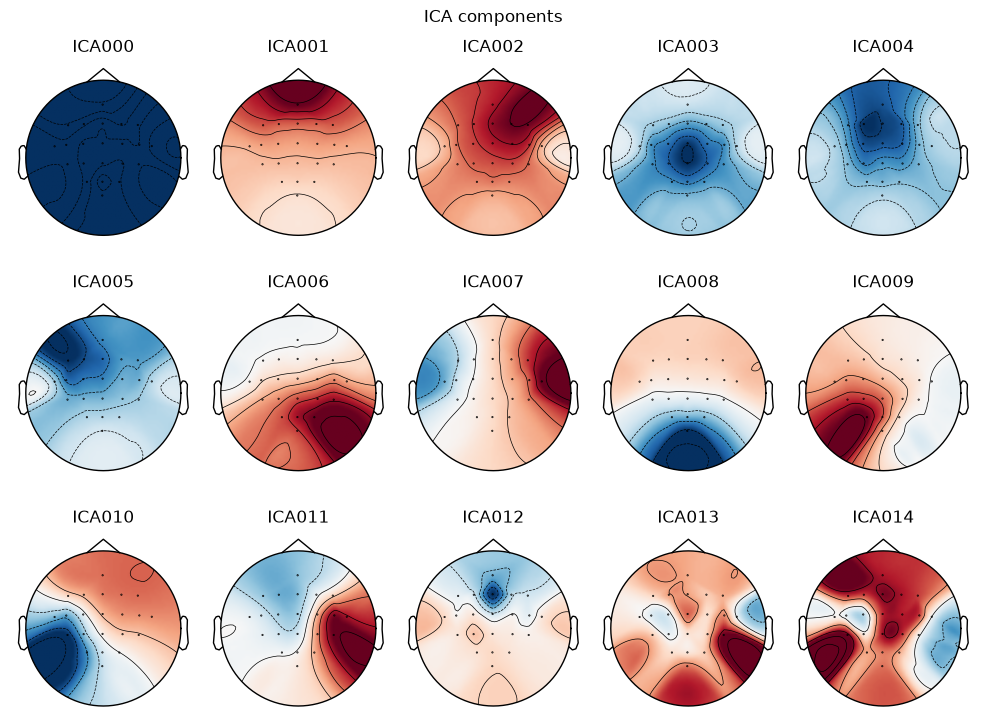

In [3]:
ica.plot_components()

In [ ]:
ica = ICA(n_components=12, max_iter='auto', random_state=97) # 위의 노이즈 제거에서 독립 성분이 제거되었으니 n_componets를 줄여봤다. 논리적 근거는 없음.
ica.fit(raw_clean)

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 12 components
Fitting ICA took 46.7s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,67 iterations on raw data (672528 samples)
ICA components,12
Available PCA components,22
Channel types,eeg
ICA components marked for exclusion,—


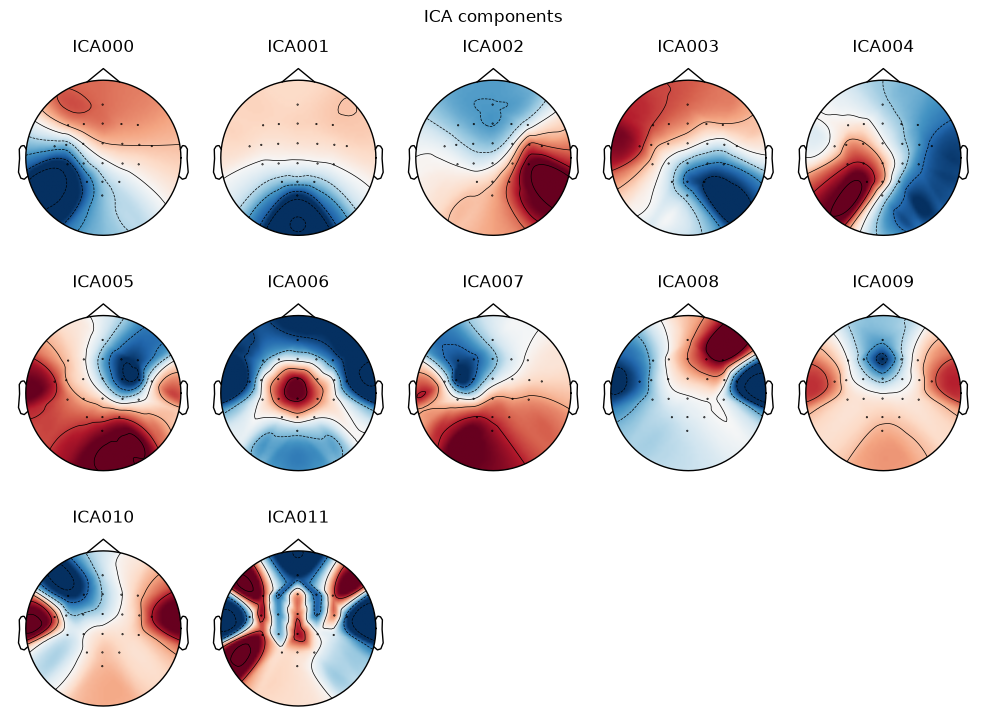

In [7]:
ica.plot_components()

# 가설 1-1 결과분석
ICA 011이 그럴듯한데 다른 방식으로도 확인이 필요할 듯.

# 가설확인 1-2.
위의 가설 1-1의 결과와는 다른 방식으로 확인이 필요.  
그래서 TFR map(Time-Frequency Representation)을 사용해서 특정 주파수(8~30)의 파워값을 time 도메인으로 확인한다.  
- 뮤파 : 정수리(운동피질)에서 8~13Hz로 나타남. MI 때 ERD로 인한 진폭 감소가 발생.
- 베타파 : 전두엽 및 운동피질에서 13~30Hz로 나타남. MI 때 ERD로 인한 진폭 감소가 발생.

-> 우선 왼손 상상의 경우만 확인할 것이고, 주파수 대역은 8~30Hz, 전극 위치는 C1/C2와 C3/C4이다.  
ERD를 확인할 것이기에 좌우반구의 파워 차이를 확인해야 한다.

In [6]:
# ICA로 노이즈 제거

import mne
from mne.preprocessing import ICA

print("--- 🚜 최강의 교차 정제 파이프라인 가동 (1~30Hz 광대역 ICA) ---")

# ==========================================
# [트랙 A] 범인 몽타주 확보용 넓은 그물망 (1~30Hz)
# ==========================================
print("1. 모든 노이즈(EOG, 알파파, 근육)를 잡기 위한 1~30Hz 필터링 및 ICA 학습")
raw_for_ica = raw_data.copy().filter(l_freq=1.0, h_freq=30.0)

ica = ICA(n_components=15, max_iter='auto', random_state=97)
ica.fit(raw_for_ica)

# EOG 채널과 비교하여 1차 범인 자동 색출
eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica)
print(f"🕵️‍♂️ 1차 자동 색출된 EOG 성분: {eog_indices}")


# ==========================================
# [트랙 B] AI에게 먹일 진짜 뇌파 준비 (8~30Hz)
# ==========================================
print("2. AI 학습을 위한 8~30Hz 타겟 뇌파 준비")
raw_for_ai = raw_data.copy().filter(l_freq=8.0, h_freq=30.0)
# ==========================================
# [크로스 오버] 트랙 A의 ICA를 트랙 B에 들이받기!
# ==========================================
print("3. 광대역에서 찾은 모든 범인 몽타주를 8~30Hz 데이터에 적용하여 영구 제외")
raw_clean = raw_for_ai.copy()


# 핵심: 1~30Hz에서 똑똑하게 학습된 ica를 8~30Hz 타겟 데이터에 적용!
ica.apply(raw_clean, exclude=eog_indices)
# 2. CAR 적용 (전압 기준점 평탄화)
raw_clean.set_eeg_reference('average', projection=False)
"""
# 4. 정제 결과 확인
raw_for_ai.plot(n_channels=5, title="Before ICA (8-30Hz)")
raw_clean.plot(n_channels=5, title="After ICA (8-30Hz Cleaned)")
"""
print("--- 🎉 무결점 정제 완료! ---")


# ------------------------------------------------------- 에포킹

print("--- 🚜 9일 차: 에포킹 불도저 가동 ---")

# 1. 뇌파 데이터 안에 숨겨진 '지시 타이밍(이벤트)' 추출
events, event_dict = mne.events_from_annotations(raw_clean)
print(f"발견된 이벤트 종류: {event_dict}")

# 2. 데이터 싹둑 썰기 (Cue 기준 -1.0초 ~ 4.0초) -> MI는 약 4초간 지속하게 실험을 진행함.
# baseline=(-1.0, 0.0)은 지시가 내려지기 전 1초를 '영점(기준점)'으로 잡겠다는 의미입니다.
epochs = mne.Epochs(raw_clean, events, tmin=-1.0, tmax=4.0, event_id = event_dict, baseline=(-1.0, 0.0), preload=True, event_repeated="drop")
    # event_id는 자동적으로 1,2, ... 으로 제공되지만 이미 event_id가 따로 있다면 event_id=event_dict으로 정보를 주고, preload=True로 해당 event_dict을 event_id로 쓰게 한다.
    # event_repeated 옵션은 하나의 시간(타임 스탬프)에 여러 이벤트 플래그가 있을 때 문제를 해결하기 위한 옵션. drop과 merge가 있다.


--- 🚜 최강의 교차 정제 파이프라인 가동 (1~30Hz 광대역 ICA) ---
1. 모든 노이즈(EOG, 알파파, 근육)를 잡기 위한 1~30Hz 필터링 및 ICA 학습
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 825 samples (3.300 s)

Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 31.6s.
Using EOG channels: EOG-left, EOG-central, EOG-right
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and rev

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mne.time_frequency import tfr_morlet


# 0. 왼손 상상 에포크만 가져오기(데이터 설명 pdf에서 왼손 상상 에포크는 769임을 확인. + epochs.event_id로 실제로 존재함 확인.)
epochs_left = epochs['769']

# 1. 추적할 주파수 대역 설정 (Mu 밴드를 포함한 8~30Hz)
freqs = np.arange(8.0, 31.0, 1.0)
n_cycles = freqs / 2.0 

print("시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)")
# 2. 왼손 상상 데이터(epochs_left)의 TFR 계산 -> TFR에는  EpochsTFR과 AverageTFR이 있고, 여기선 Epochs TFR이다. -> Epochs TFR은 아래 vmin, vmax를 쓸 수 없다.
power_left = tfr_morlet(epochs_left, freqs=freqs, n_cycles=n_cycles, use_fft=True,
                        return_itc=False, decim=3, n_jobs=1, average=True)

# 3. ERD/ERS 시각화 (C1/C2, C3/C4 전극)
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 15)) # 2행 2열구조(1행 C1/C2, 2행 C3/C4)

# C1/C2, C3/C4의 그래프 설정 (vmin, vmax는 Epochs TFR에서 쓸 수 없다.)

power_left.plot(picks=['C1'], baseline=(-1.0, 0), mode='percent', 
                axes=ax[0][0], title="ERD/ERS Map: Left Hand MI at C1", 
                show=False) 
ax[0][0].axvline(0, color='black', linestyle='--', linewidth=2) # 지시 시점(0초) 기준선

power_left.plot(picks=['C2'], baseline=(-1.0, 0), mode='percent', 
                axes=ax[0][1], title="ERD/ERS Map: Left Hand MI at C2", 
                show=False) 
ax[0][1].axvline(0, color='black', linestyle='--', linewidth=2)



power_left.plot(picks=['C3'], baseline=(-1.0, 0), mode='percent', 
                axes=ax[1][0], title="ERD/ERS Map: Left Hand MI at C3", 
                show=False) 
ax[1][0].axvline(0, color='black', linestyle='--', linewidth=2)


power_left.plot(picks=['C4'], baseline=(-1.0, 0), mode='percent', 
                axes=ax[1][1], title="ERD/ERS Map: Left Hand MI at C4", 
                show=False) 

ax[1][1].axvline(0, color='black', linestyle='--', linewidth=2)



plt.tight_layout()
plt.show()


시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


# 가설 1-2 결과 분석
왼손 상상 시의 ERD를 확인하기 위해 C1/C2, C3/C4의 8~30Hz 구간의 TFR map을 확인했다.  
확인 결과, C1/C2, C3/C4 모두 지시 직전과 비교하여 확연히 파워가 감소했다. 이는 왼손 상상으로 인한 ERD가 발생했다고 생각된다. 문제는 아래 특이점들에서 발생한다. ERD를 확인한다는 건 
- 특이점 1. 왼손 상상 중에도 약 12~20Hz 구간은 다른 구간에 비해 덜 감소하거나 오히려 지시 전보다 증가(빨간색)하기도 한다.  
- 특이점 2. C1/C2가 C3/C4에 비해 특이점 1이 덜 보인다. 자세히 말하면 C3/C4는 12~20Hz 구간의 파워가 지시(0초)후에 4초간 대부분 빨간색이지만 C1/C2는 띄엄띄엄있다.
  
특이점 1에 대한 설명 : 운동 억제를 위한 low beta 대역에 ERS가 나타남. 이론적으론 왼손 상상시에 C4엔 강한 ERD, 반대쪽인 C3에 low beta 대역에 ERS가 나타남. 그러나 (1) 두피에서 측정하는 뇌파(EEG)의 단점인 낮은 공간 해상도(뇌파가 사방으로 퍼짐) (2) 피험자의 미숙으로 인한 양쪽 손 상상 으로 인해 C3, C4 모두에서 low beta ERS가 나타날 수 있음. 이 2가지 이유는 ERD에도 똑같이 적용되어 좌우반구 상관없이 ERD도 유사하게 나타남.

특이점 2에 대한 설명 : C1/C2는 중앙선에 더 가까우며 주로 몸통이나 다리, 보완운동영역(SMA)  에 더 연관이 깊다. C3/C4는 일차운동피질(M1)의 외측에 위치하며 손과 팔의 제어를 담당하기에 C1/C2 보다 C3/C4가 ERD나 ERS의 특성이 더 뚜렷이 나타난다.  
<br><br>
추가로 왼/오른손 MI 분류에서 좌우반구의 ERD 적용 차이로 인한 대비를 잡아내는 것이 핵심이다. 왼손 상상 시에 우반구의 C2, C4가 좌반구의 C1, C3보다 좀 더 파란색이 진하다거나 파란색인 주파수가 더 넓다거나 하는 차이가 있음을 확인할 수 있다.  
-> 추가 실험 : C1/C2와 C3/C4 중에 뭐가 더 대비가 잘 되나 확인하기 위해서 다른 피험자들의 TFR map도 확인할 필요가 있다.

# 가설 1-2에 대한 추가 실험
C1/C2와 C3/C4 중에 뭐가 더 대비가 잘 되나 확인하기 위해서 다른 피험자들의 TFR map도 확인할 필요가 있다.  
확인은 시각적으로 파란 부분의 진하기가 양쪽 반구에서 차이가 뚜렷이 나는가(우반구가 더 진해야 함.), 파란 부분의 주파수 대역이 양쪽 반구에서 뚜렷이 차이가 나는가(우반구가 더 넓어야 함.)를 비교해서 위 2개의 차이가 더 뚜렷한 전극을 사용하는 걸로.

In [ ]:
# matplotlib에서 출력한 이미지(그래프 포함)은 새 창으로 열림.
%matplotlib qt

import pandas as pd
import mne
from mne.preprocessing import ICA

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
# 1. 데이터 불러오고 형태 및 결측치 확인.
subj_list = ['01', '02', '03', '04', '05', '06', '07', '08', '09']
epochs_subj_list = []


for subj in subj_list : 
    file_path = rf"../dataset/A{subj}T.gdf"

    print("1-1. gdf 데이터 로딩 중--------------")
    raw_data = mne.io.read_raw_gdf(file_path, preload=True)


    df = raw_data.to_data_frame()

    print("1-2. 결측치 확인--------------")
    print(df.info())

    """"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    # 2. 채널 타입 정정 및 이름 수정 후, 몽타주 적용
    # 2-1. mne 라이브러리가 자동으로 EOG 채널을 EEG 채널이라 저장해둬서 정정해야 함. -> 딕셔너리 이용
    print("1. EOG 채널 타입 정정") # -> set_chnnel_types() 사용

    eog_dict = {
        'EOG-left': 'eog',
        'EOG-central': 'eog',
        'EOG-right': 'eog'
    }

    # MNE 객체에 직업 변경 사항을 적용합니다.
    raw_data.set_channel_types(eog_dict)



    # 2-2. 10-10 시스템(Extended 10-20 system) 표준 명칭으로 이름표 교체 -> Extended 10-20 system은 다양해서 훨씬 많고 다양한 위치의 전극을 허용한다. make_standard_montage('standard_1020')를 통해서 표준 10-20 시스템 뿐만 아니라 확장된 버전도 적용 가능하다. 이것이 10-20 시스템의 장점.(확장성)
    print("2. 실험에서 채택한 10-20 시스템의 확장판에 맞게 montage 설정하기 위해 EEG 채널 이름을 표준에 맞는 이름으로 재설정") # -> rename_chnnels() 사용

    channel_rename_dict = {
        'EEG-Fz': 'Fz',
        'EEG-0': 'FC3',  'EEG-1': 'FC1',  'EEG-2': 'FCz',  'EEG-3': 'FC2',  'EEG-4': 'FC4',
        'EEG-5': 'C5',   'EEG-C3': 'C3',  'EEG-6': 'C1',   'EEG-Cz': 'Cz',  'EEG-7': 'C2',   'EEG-C4': 'C4',  'EEG-8': 'C6',
        'EEG-9': 'CP3',  'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
        'EEG-14': 'P1',  'EEG-Pz': 'Pz',  'EEG-15': 'P2',
        'EEG-16': 'POz'
    }
    raw_data.rename_channels(channel_rename_dict)
    
    print("2. 10-20 국제 표준 두피 지도를 가져와서 데이터에 씌웁니다.")
    
    # MNE 라이브러리 안에 내장된 'standard_1020' 지도를 꺼내옵니다.
    montage = mne.channels.make_standard_montage('standard_1020')

    # 꺼내온 지도를 우리 데이터에 찰칵! 하고 덮어씌웁니다.
    raw_data.set_montage(montage)
    
    print("--- 🚜 최강의 교차 정제 파이프라인 가동 (1~30Hz 광대역 ICA) ---")

    # ==========================================
    # [트랙 A] 범인 몽타주 확보용 넓은 그물망 (1~30Hz)
    # ==========================================
    print("1. 모든 노이즈(EOG, 알파파, 근육)를 잡기 위한 1~30Hz 필터링 및 ICA 학습")
    raw_for_ica = raw_data.copy().filter(l_freq=1.0, h_freq=30.0)

    ica = ICA(n_components=15, max_iter='auto', random_state=97)
    ica.fit(raw_for_ica)

    # EOG 채널과 비교하여 1차 범인 자동 색출
    eog_indices, eog_scores = ica.find_bads_eog(raw_for_ica)
    print(f"🕵️‍♂️ 1차 자동 색출된 EOG 성분: {eog_indices}")


    # ==========================================
    # [트랙 B] AI에게 먹일 진짜 뇌파 준비 (8~30Hz)
    # ==========================================
    print("2. AI 학습을 위한 8~30Hz 타겟 뇌파 준비")
    raw_for_ai = raw_data.copy().filter(l_freq=8.0, h_freq=30.0)
    # ==========================================
    # [크로스 오버] 트랙 A의 ICA를 트랙 B에 들이받기!
    # ==========================================
    print("3. 광대역에서 찾은 모든 범인 몽타주를 8~30Hz 데이터에 적용하여 영구 제외")
    raw_clean = raw_for_ai.copy()


    # 핵심: 1~30Hz에서 똑똑하게 학습된 ica를 8~30Hz 타겟 데이터에 적용!
    ica.apply(raw_clean, exclude=eog_indices)
    # 2. CAR 적용 (전압 기준점 평탄화)
    raw_clean.set_eeg_reference('average', projection=False)

    print("--- 🎉 무결점 정제 완료! ---")


    # ------------------------------------------------------- 에포킹

    print("--- 에포킹 시작---")

    # 1. 뇌파 데이터 안에 숨겨진 '지시 타이밍(이벤트)' 추출
    events, event_dict = mne.events_from_annotations(raw_clean)
    print(f"발견된 이벤트 종류: {event_dict}")

    # 2. 데이터 싹둑 썰기 (Cue 기준 -1.0초 ~ 4.0초) -> MI는 약 4초간 지속하게 실험을 진행함.
    # baseline=(-1.0, 0.0)은 지시가 내려지기 전 1초를 '영점(기준점)'으로 잡겠다는 의미입니다.
    epochs = mne.Epochs(raw_clean, events, tmin=-1.0, tmax=4.0, event_id = event_dict, baseline=(-1.0, 0.0), preload=True, event_repeated="drop")
    # event_id는 자동적으로 1,2, ... 으로 제공되지만 이미 event_id가 따로 있다면 event_id=event_dict으로 정보를 주고, preload=True로 해당 event_dict을 event_id로 쓰게 한다.
    # event_repeated 옵션은 하나의 시간(타임 스탬프)에 여러 이벤트 플래그가 있을 때 문제를 해결하기 위한 옵션. drop과 merge가 있다.

    epochs_subj_list.append(epochs)

print("끝")

1-1. gdf 데이터 로딩 중--------------
Extracting GDF parameters from ../dataset/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


C:\Python312\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


1-2. 결측치 확인--------------
<class 'pandas.DataFrame'>
RangeIndex: 672528 entries, 0 to 672527
Data columns (total 26 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   time         672528 non-null  float64
 1   EEG-Fz       672528 non-null  float64
 2   EEG-0        672528 non-null  float64
 3   EEG-1        672528 non-null  float64
 4   EEG-2        672528 non-null  float64
 5   EEG-3        672528 non-null  float64
 6   EEG-4        672528 non-null  float64
 7   EEG-5        672528 non-null  float64
 8   EEG-C3       672528 non-null  float64
 9   EEG-6        672528 non-null  float64
 10  EEG-Cz       672528 non-null  float64
 11  EEG-7        672528 non-null  float64
 12  EEG-C4       672528 non-null  float64
 13  EEG-8        672528 non-null  float64
 14  EEG-9        672528 non-null  float64
 15  EEG-10       672528 non-null  float64
 16  EEG-11       672528 non-null  float64
 17  EEG-12       672528 non-null  float64
 18  EEG-13   

C:\Python312\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


1-2. 결측치 확인--------------
<class 'pandas.DataFrame'>
RangeIndex: 677169 entries, 0 to 677168
Data columns (total 26 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   time         677169 non-null  float64
 1   EEG-Fz       677169 non-null  float64
 2   EEG-0        677169 non-null  float64
 3   EEG-1        677169 non-null  float64
 4   EEG-2        677169 non-null  float64
 5   EEG-3        677169 non-null  float64
 6   EEG-4        677169 non-null  float64
 7   EEG-5        677169 non-null  float64
 8   EEG-C3       677169 non-null  float64
 9   EEG-6        677169 non-null  float64
 10  EEG-Cz       677169 non-null  float64
 11  EEG-7        677169 non-null  float64
 12  EEG-C4       677169 non-null  float64
 13  EEG-8        677169 non-null  float64
 14  EEG-9        677169 non-null  float64
 15  EEG-10       677169 non-null  float64
 16  EEG-11       677169 non-null  float64
 17  EEG-12       677169 non-null  float64
 18  EEG-13   

...

1-2. 결측치 확인--------------
<class 'pandas.DataFrame'>
RangeIndex: 660530 entries, 0 to 660529
Data columns (total 26 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   time         660530 non-null  float64
 1   EEG-Fz       660530 non-null  float64
 2   EEG-0        660530 non-null  float64
 3   EEG-1        660530 non-null  float64
 4   EEG-2        660530 non-null  float64
 5   EEG-3        660530 non-null  float64
 6   EEG-4        660530 non-null  float64
 7   EEG-5        660530 non-null  float64
 8   EEG-C3       660530 non-null  float64
 9   EEG-6        660530 non-null  float64
 10  EEG-Cz       660530 non-null  float64
 11  EEG-7        660530 non-null  float64
 12  EEG-C4       660530 non-null  float64
 13  EEG-8        660530 non-null  float64
 14  EEG-9        660530 non-null  float64
 15  EEG-10       660530 non-null  float64
 16  EEG-11       660530 non-null  float64
 17  EEG-12       660530 non-null  float64
 18  EEG-13   

C:\Python312\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


1-2. 결측치 확인--------------
<class 'pandas.DataFrame'>
RangeIndex: 600915 entries, 0 to 600914
Data columns (total 26 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   time         600915 non-null  float64
 1   EEG-Fz       600915 non-null  float64
 2   EEG-0        600915 non-null  float64
 3   EEG-1        600915 non-null  float64
 4   EEG-2        600915 non-null  float64
 5   EEG-3        600915 non-null  float64
 6   EEG-4        600915 non-null  float64
 7   EEG-5        600915 non-null  float64
 8   EEG-C3       600915 non-null  float64
 9   EEG-6        600915 non-null  float64
 10  EEG-Cz       600915 non-null  float64
 11  EEG-7        600915 non-null  float64
 12  EEG-C4       600915 non-null  float64
 13  EEG-8        600915 non-null  float64
 14  EEG-9        600915 non-null  float64
 15  EEG-10       600915 non-null  float64
 16  EEG-11       600915 non-null  float64
 17  EEG-12       600915 non-null  float64
 18  EEG-13   

C:\Python312\Lib\contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


1-2. 결측치 확인--------------
<class 'pandas.DataFrame'>
RangeIndex: 686120 entries, 0 to 686119
Data columns (total 26 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   time         686120 non-null  float64
 1   EEG-Fz       686120 non-null  float64
 2   EEG-0        686120 non-null  float64
 3   EEG-1        686120 non-null  float64
 4   EEG-2        686120 non-null  float64
 5   EEG-3        686120 non-null  float64
 6   EEG-4        686120 non-null  float64
 7   EEG-5        686120 non-null  float64
 8   EEG-C3       686120 non-null  float64
 9   EEG-6        686120 non-null  float64
 10  EEG-Cz       686120 non-null  float64
 11  EEG-7        686120 non-null  float64
 12  EEG-C4       686120 non-null  float64
 13  EEG-8        686120 non-null  float64
 14  EEG-9        686120 non-null  float64
 15  EEG-10       686120 non-null  float64
 16  EEG-11       686120 non-null  float64
 17  EEG-12       686120 non-null  float64
 18  EEG-13   

In [ ]:
# 노이즈 제거되고 에포킹 된 결과물 subj마다 저장하기.
for i in range(9): # zip(subj_list, epochs_subj_list)를 쓰는 방법도 있음.
    save_path = rf"../dataset/epochs/A0{i+1}T-epoch.fif"
    epochs_subj_list[i].save(save_path, overwrite=True)
    print(f"💾 Subj {i+1} Epochs 저장 완료: {save_path}\n")
    
    


Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


C:\Users\hum05\AppData\Local\Temp\ipykernel_7816\799502599.py:4: RuntimeWarning: This filename (../dataset/epochs/A01T-epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_subj_list[i].save(save_path, overwrite=True)


💾 Subj 1 Epochs 저장 완료: ../dataset/epochs/A01T-epoch.fif

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


C:\Users\hum05\AppData\Local\Temp\ipykernel_7816\799502599.py:4: RuntimeWarning: This filename (../dataset/epochs/A02T-epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_subj_list[i].save(save_path, overwrite=True)


💾 Subj 2 Epochs 저장 완료: ../dataset/epochs/A02T-epoch.fif

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


...

💾 Subj 8 Epochs 저장 완료: ../dataset/epochs/A08T-epoch.fif

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


C:\Users\hum05\AppData\Local\Temp\ipykernel_7816\799502599.py:4: RuntimeWarning: This filename (../dataset/epochs/A09T-epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_subj_list[i].save(save_path, overwrite=True)


💾 Subj 9 Epochs 저장 완료: ../dataset/epochs/A09T-epoch.fif

Reading e:\workspace\BCI_Project_ICA-CSP\notebooks\..\dataset\epochs\A01T-epoch.fif ...
Isotrak not found
    Found the data of interest:
        t =   -1000.00 ...    4000.00 ms
        0 CTF compensation matrices available


C:\Users\hum05\AppData\Local\Temp\ipykernel_7816\799502599.py:10: RuntimeWarning: This filename (../dataset/epochs/A01T-epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_loaded = mne.read_epochs("../dataset/epochs/A01T-epoch.fif", preload=True)


Not setting metadata
584 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 584 events (all good), -1 – 4 s (baseline -1 – 0 s), ~139.4 MiB, data loaded,
 '32766': 8
 '768': 288
 '769': 72
 '770': 72
 '771': 72
 '772': 72>


In [6]:
# 불러오기 -> 위의 셀 실행 안하느 경우에 사용.
import mne

epochs_subj_list = []

for i in range(9) : 
    epochs_loaded = mne.read_epochs(f"../dataset/epochs/A0{i+1}T-epoch.fif", preload=True)
    epochs_subj_list.append(epochs_loaded)
    
    print(epochs_loaded)




Reading e:\workspace\BCI_Project_ICA-CSP\notebooks\..\dataset\epochs\A01T-epoch.fif ...
Isotrak not found
    Found the data of interest:
        t =   -1000.00 ...    4000.00 ms
        0 CTF compensation matrices available
Not setting metadata
584 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 584 events (all good), -1 – 4 s (baseline -1 – 0 s), ~139.4 MiB, data loaded,
 '32766': 8
 '768': 288
 '769': 72
 '770': 72
 '771': 72
 '772': 72>
Reading e:\workspace\BCI_Project_ICA-CSP\notebooks\..\dataset\epochs\A02T-epoch.fif ...


C:\Users\hum05\AppData\Local\Temp\ipykernel_6380\1855944145.py:7: RuntimeWarning: This filename (../dataset/epochs/A01T-epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_loaded = mne.read_epochs(f"../dataset/epochs/A0{i+1}T-epoch.fif", preload=True)
C:\Users\hum05\AppData\Local\Temp\ipykernel_6380\1855944145.py:7: RuntimeWarning: This filename (../dataset/epochs/A02T-epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_loaded = mne.read_epochs(f"../dataset/epochs/A0{i+1}T-epoch.fif", preload=True)


Isotrak not found
    Found the data of interest:
        t =   -1000.00 ...    4000.00 ms
        0 CTF compensation matrices available
Not setting metadata
584 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 584 events (all good), -1 – 4 s (baseline -1 – 0 s), ~139.4 MiB, data loaded,
 '32766': 8
 '768': 288
 '769': 72
 '770': 72
 '771': 72
 '772': 72>
Reading e:\workspace\BCI_Project_ICA-CSP\notebooks\..\dataset\epochs\A03T-epoch.fif ...
Isotrak not found
    Found the data of interest:
        t =   -1000.00 ...    4000.00 ms
        0 CTF compensation matrices available
Not setting metadata


C:\Users\hum05\AppData\Local\Temp\ipykernel_6380\1855944145.py:7: RuntimeWarning: This filename (../dataset/epochs/A03T-epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_loaded = mne.read_epochs(f"../dataset/epochs/A0{i+1}T-epoch.fif", preload=True)


584 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 584 events (all good), -1 – 4 s (baseline -1 – 0 s), ~139.4 MiB, data loaded,
 '32766': 8
 '768': 288
 '769': 72
 '770': 72
 '771': 72
 '772': 72>
Reading e:\workspace\BCI_Project_ICA-CSP\notebooks\..\dataset\epochs\A04T-epoch.fif ...
Isotrak not found
    Found the data of interest:
        t =   -1000.00 ...    4000.00 ms
        0 CTF compensation matrices available


...

Not setting metadata
584 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 584 events (all good), -1 – 4 s (baseline -1 – 0 s), ~139.4 MiB, data loaded,
 '32766': 8
 '768': 288
 '769': 72
 '770': 72
 '771': 72
 '772': 72>
Reading e:\workspace\BCI_Project_ICA-CSP\notebooks\..\dataset\epochs\A08T-epoch.fif ...
Isotrak not found
    Found the data of interest:
        t =   -1000.00 ...    4000.00 ms
        0 CTF compensation matrices available


C:\Users\hum05\AppData\Local\Temp\ipykernel_6380\1855944145.py:7: RuntimeWarning: This filename (../dataset/epochs/A08T-epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_loaded = mne.read_epochs(f"../dataset/epochs/A0{i+1}T-epoch.fif", preload=True)


Not setting metadata
584 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 584 events (all good), -1 – 4 s (baseline -1 – 0 s), ~139.4 MiB, data loaded,
 '32766': 8
 '768': 288
 '769': 72
 '770': 72
 '771': 72
 '772': 72>
Reading e:\workspace\BCI_Project_ICA-CSP\notebooks\..\dataset\epochs\A09T-epoch.fif ...
Isotrak not found
    Found the data of interest:
        t =   -1000.00 ...    4000.00 ms
        0 CTF compensation matrices available


C:\Users\hum05\AppData\Local\Temp\ipykernel_6380\1855944145.py:7: RuntimeWarning: This filename (../dataset/epochs/A09T-epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs_loaded = mne.read_epochs(f"../dataset/epochs/A0{i+1}T-epoch.fif", preload=True)


Not setting metadata
584 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 584 events (all good), -1 – 4 s (baseline -1 – 0 s), ~139.4 MiB, data loaded,
 '32766': 8
 '768': 288
 '769': 72
 '770': 72
 '771': 72
 '772': 72>


시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


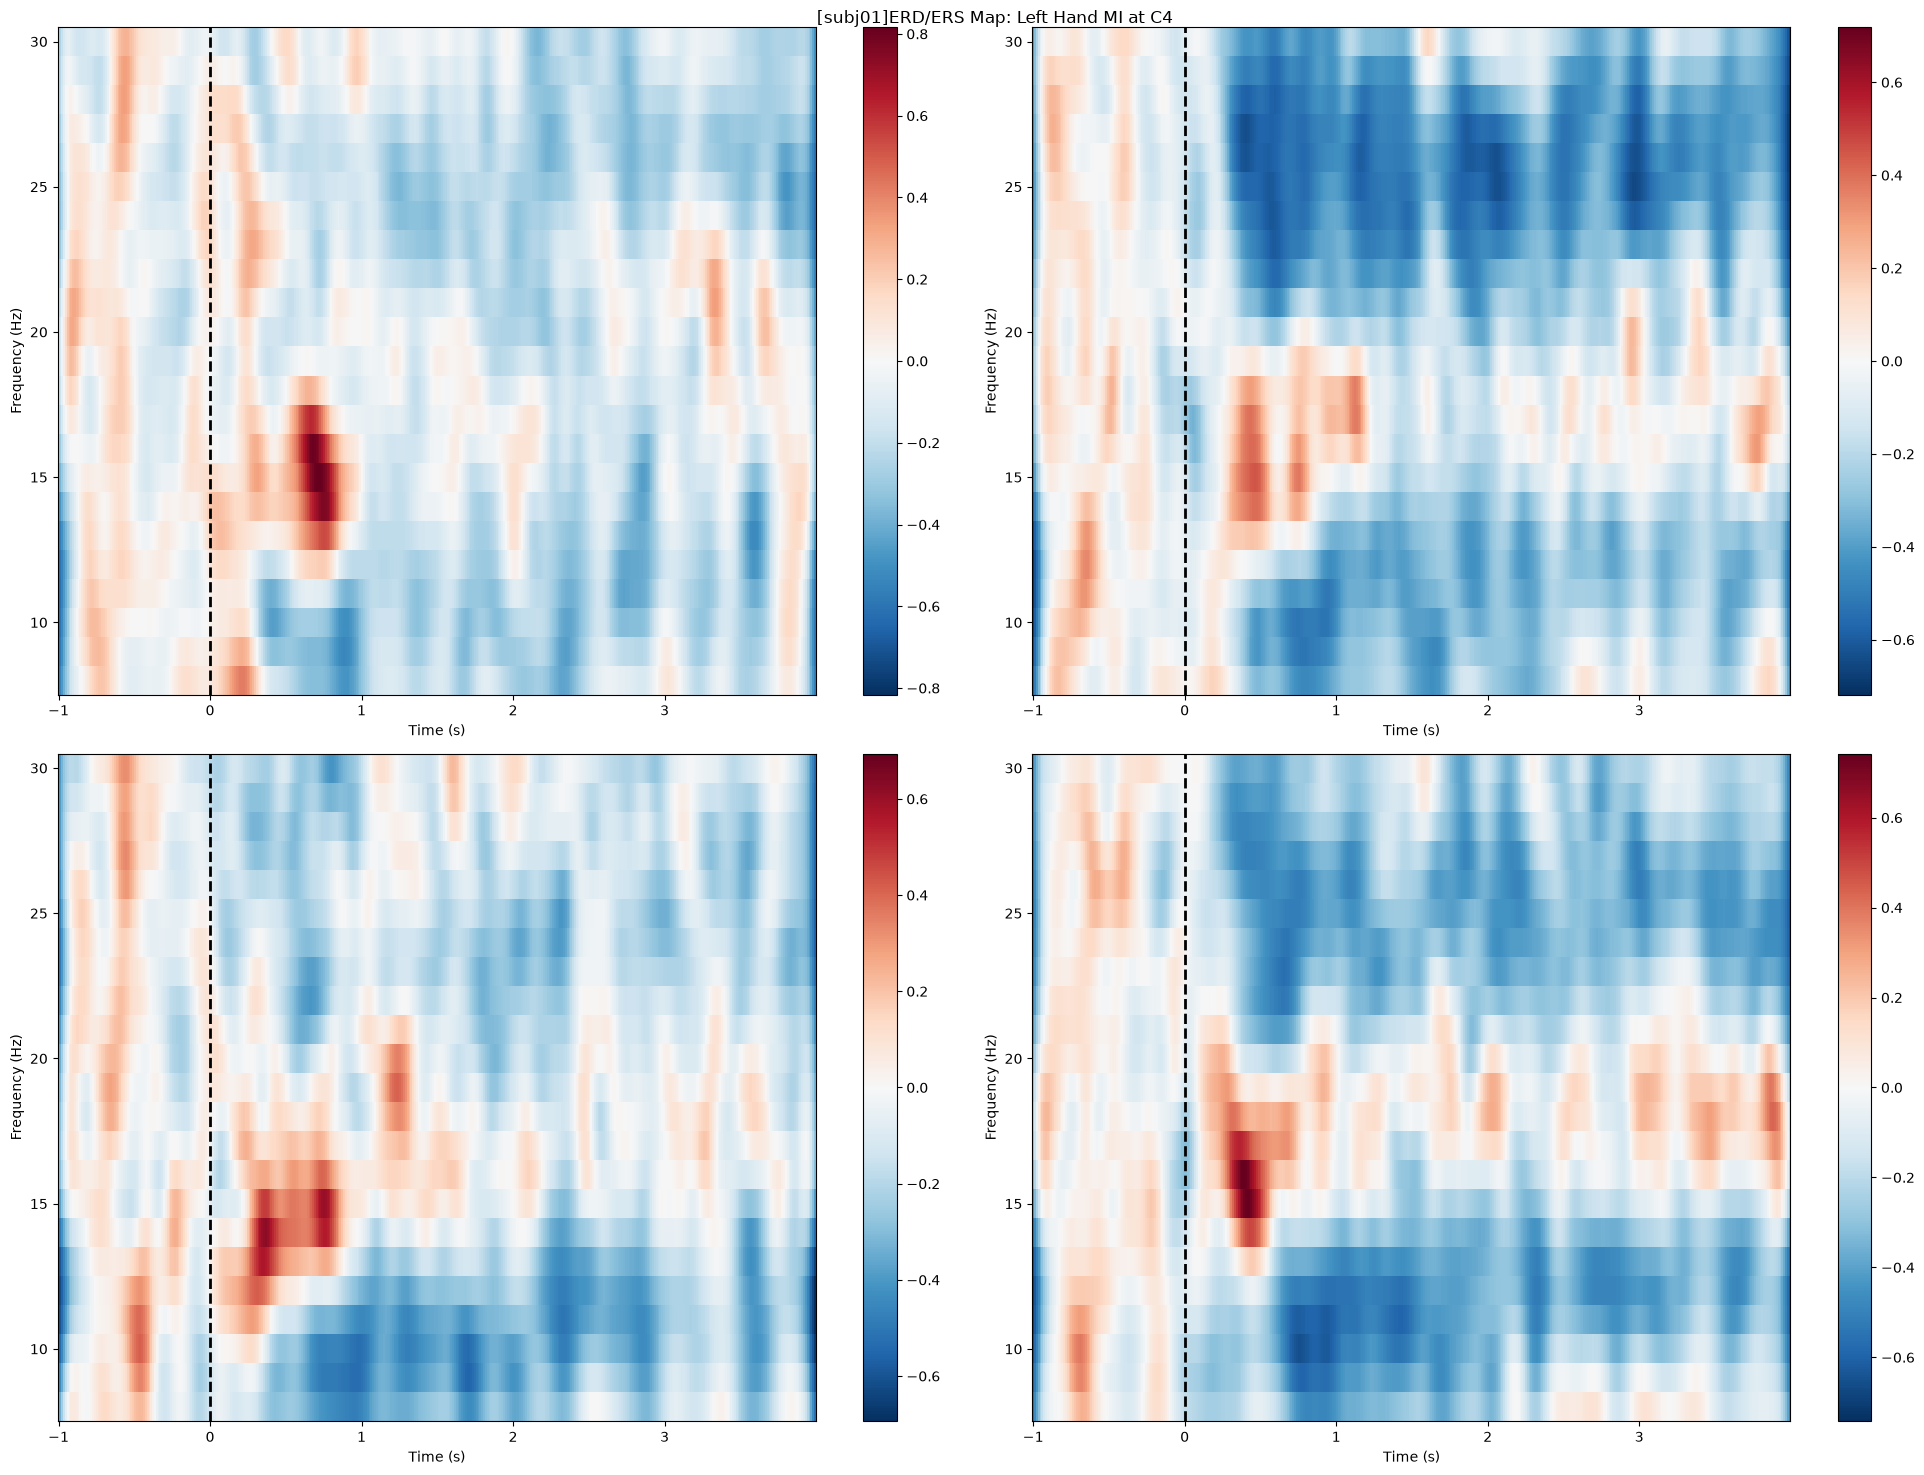

시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


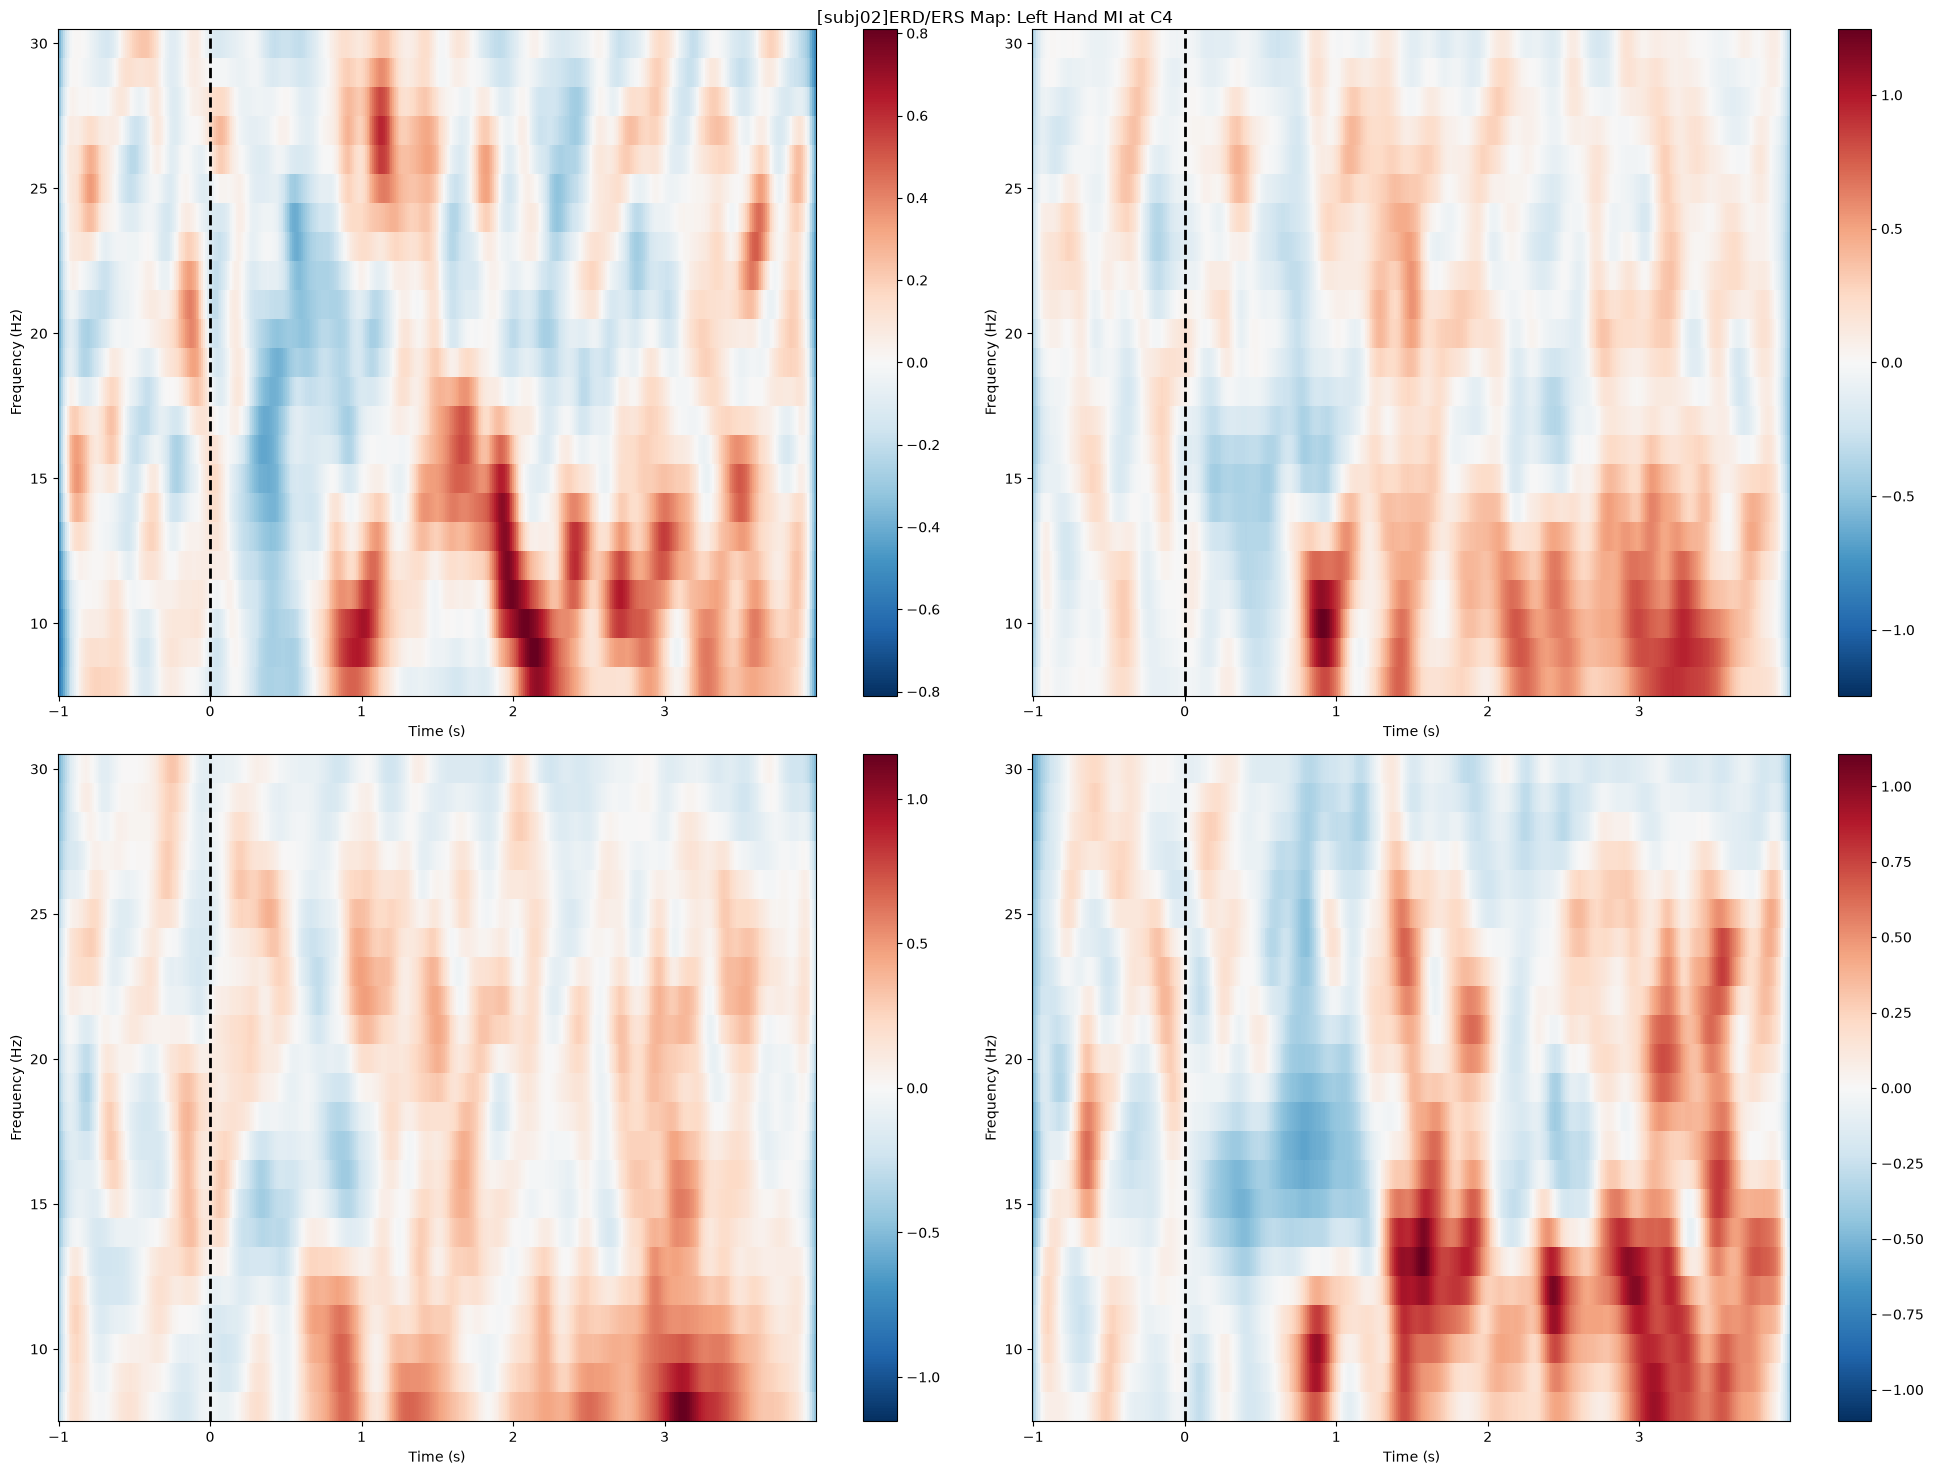

시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


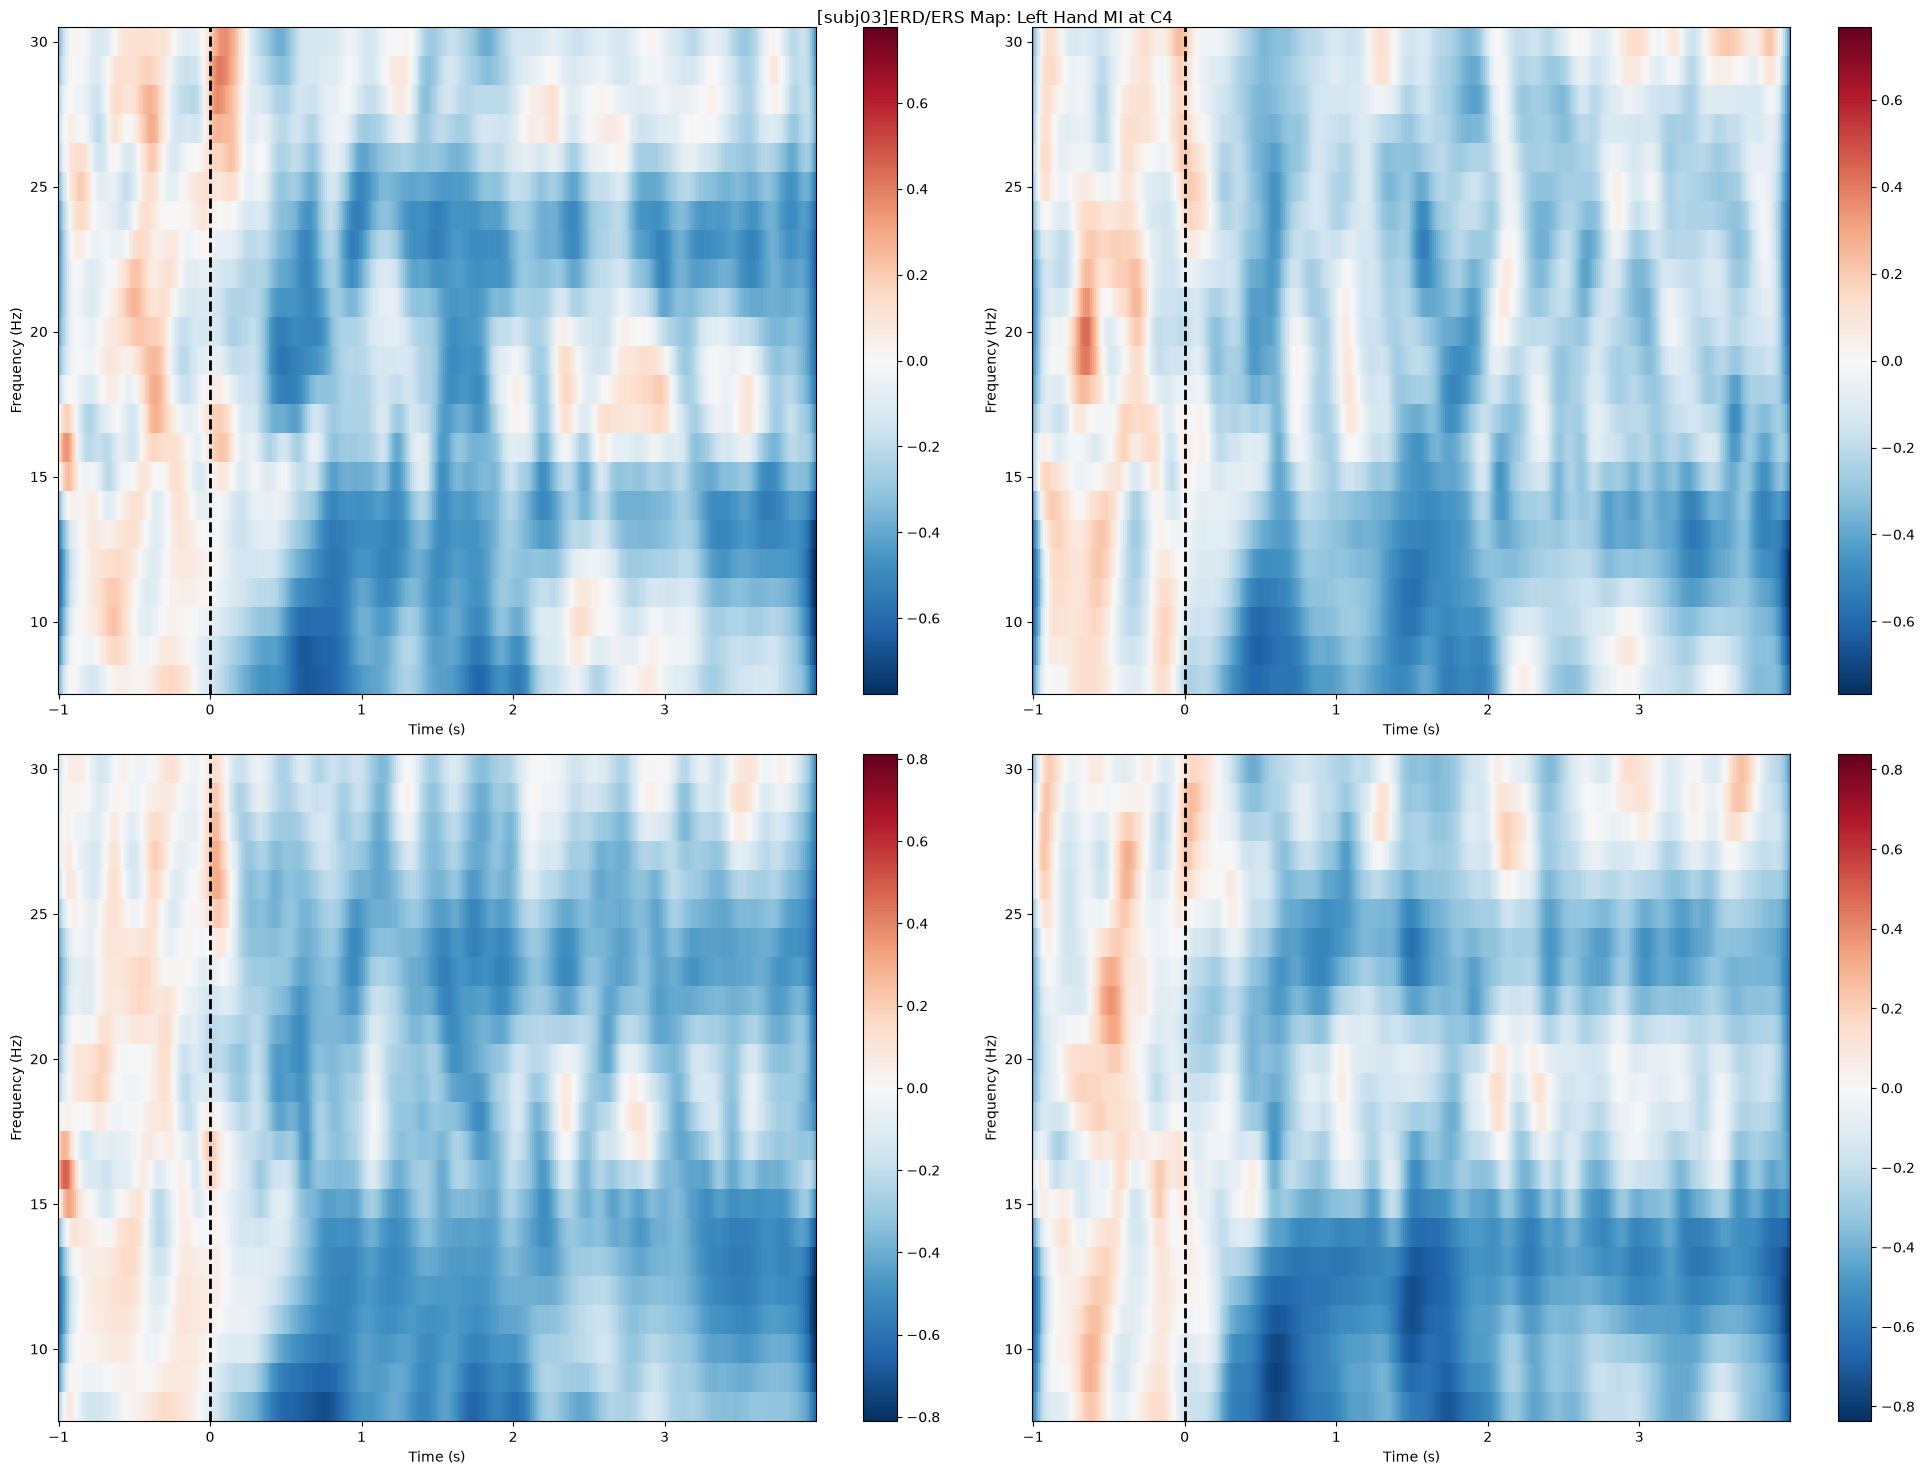

시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


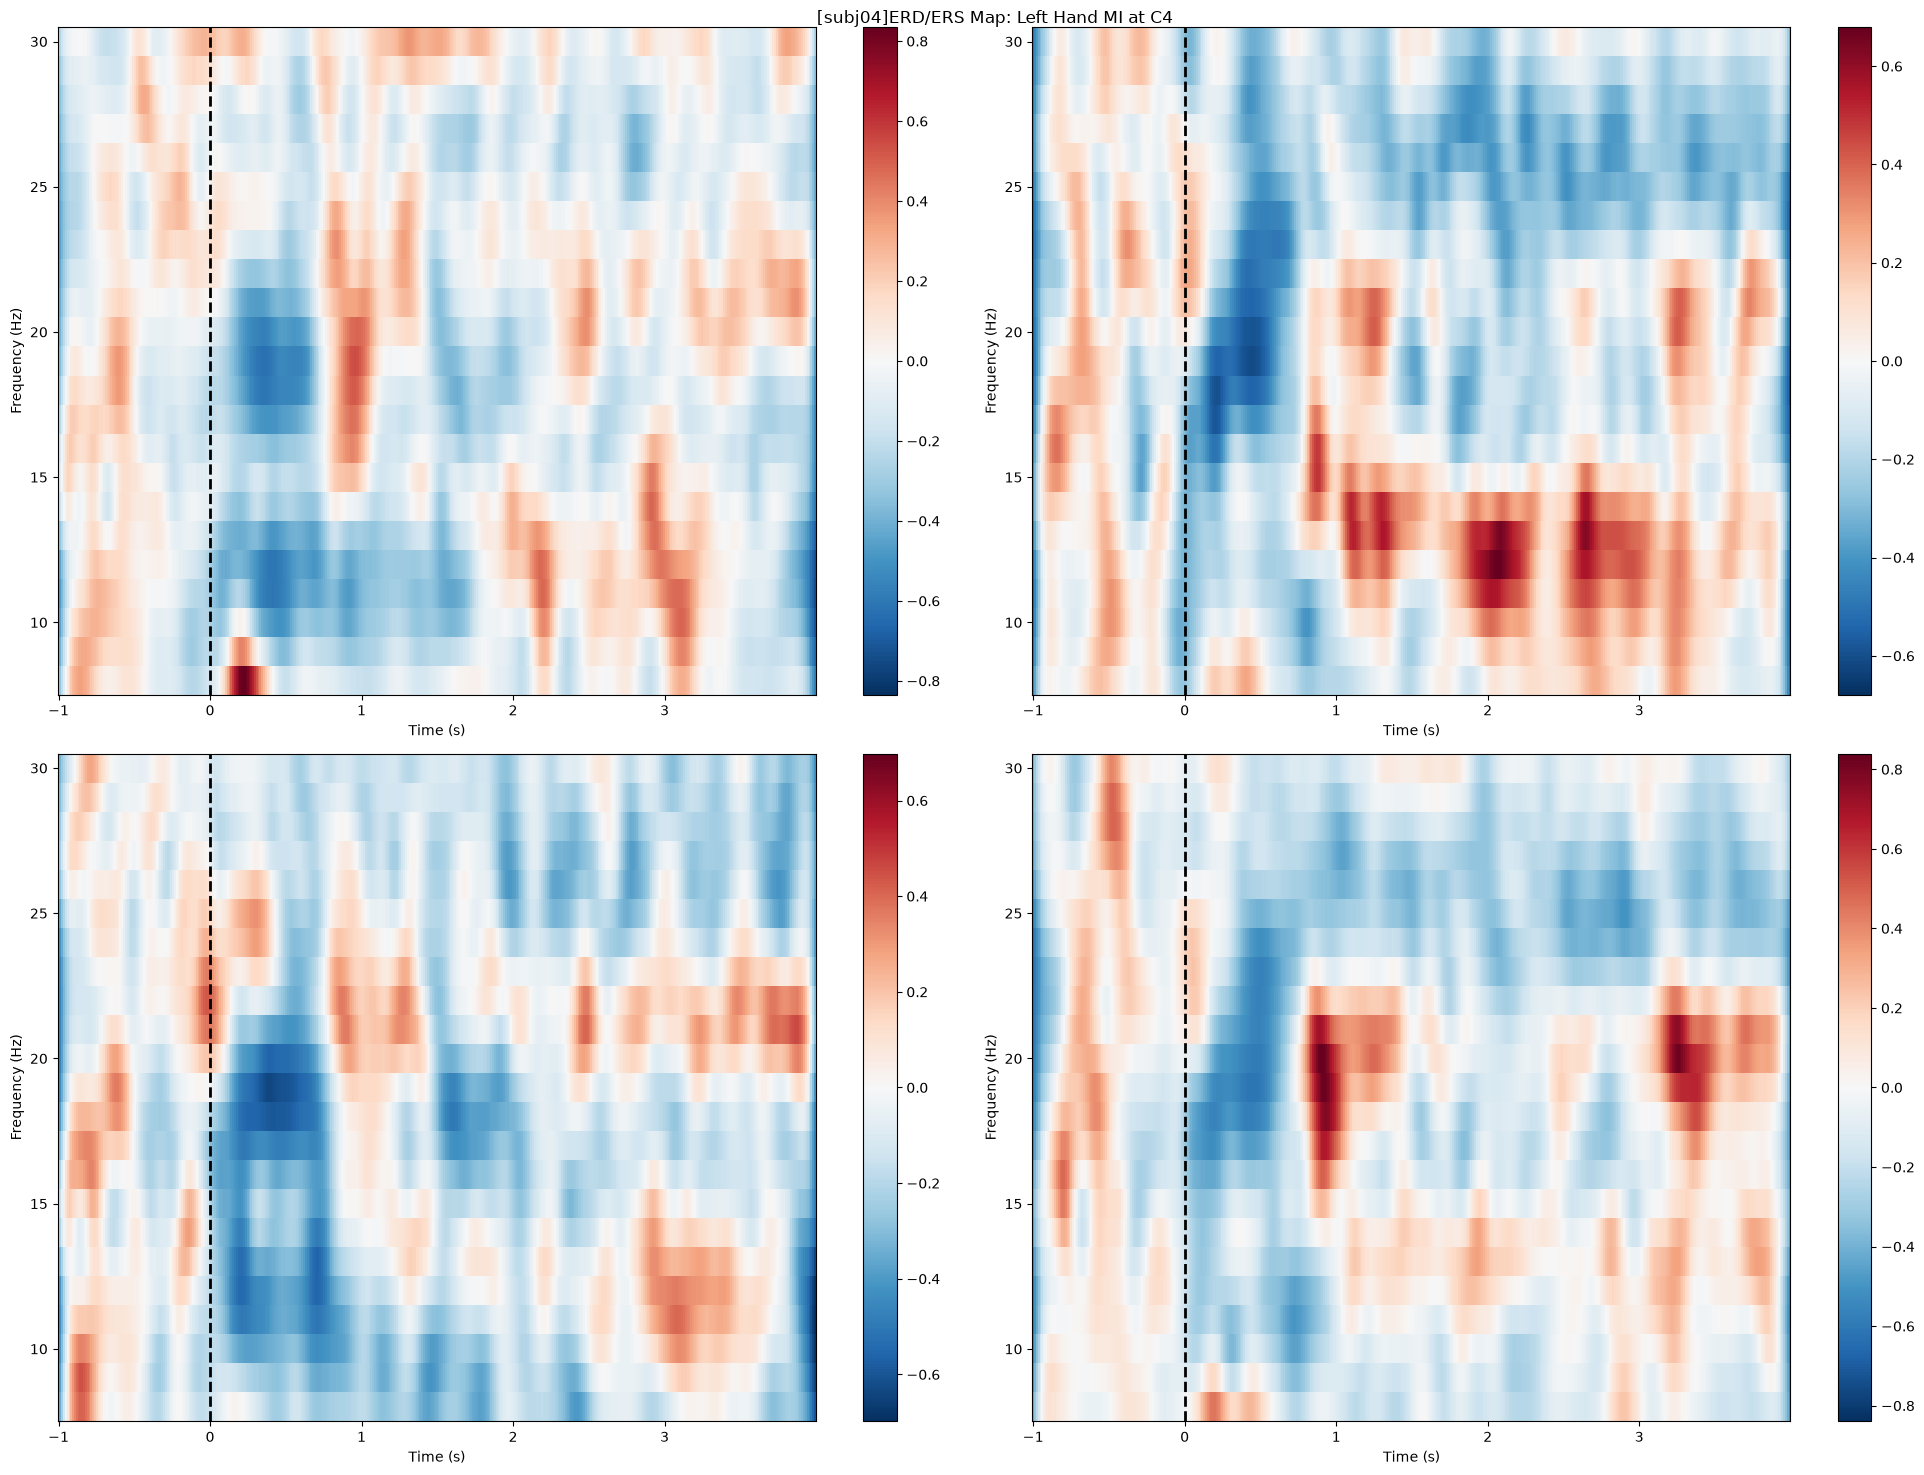

시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


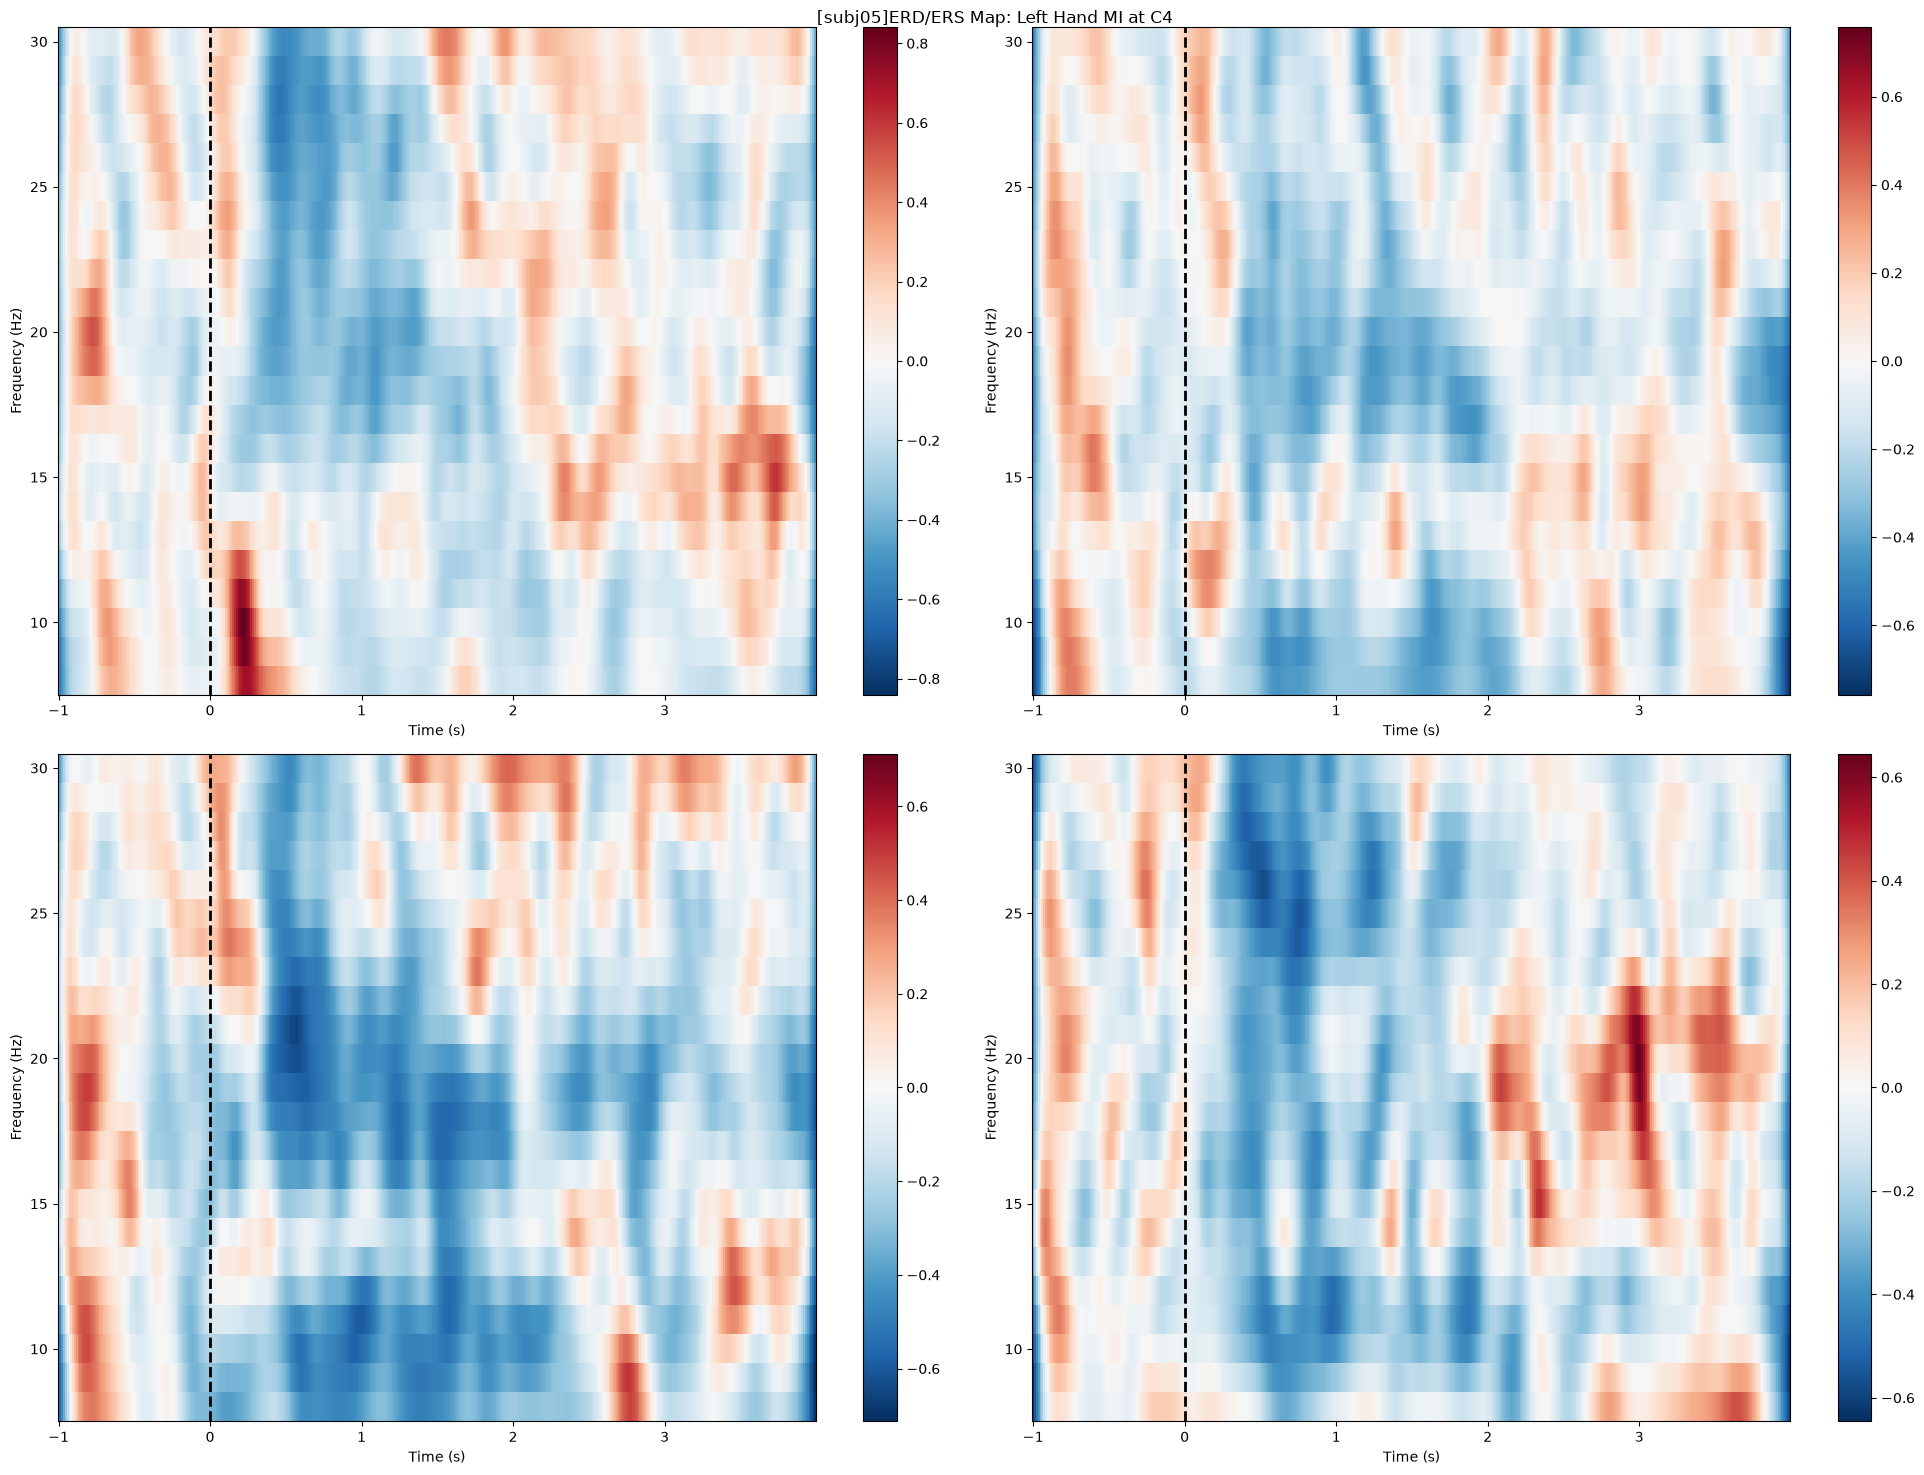

시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


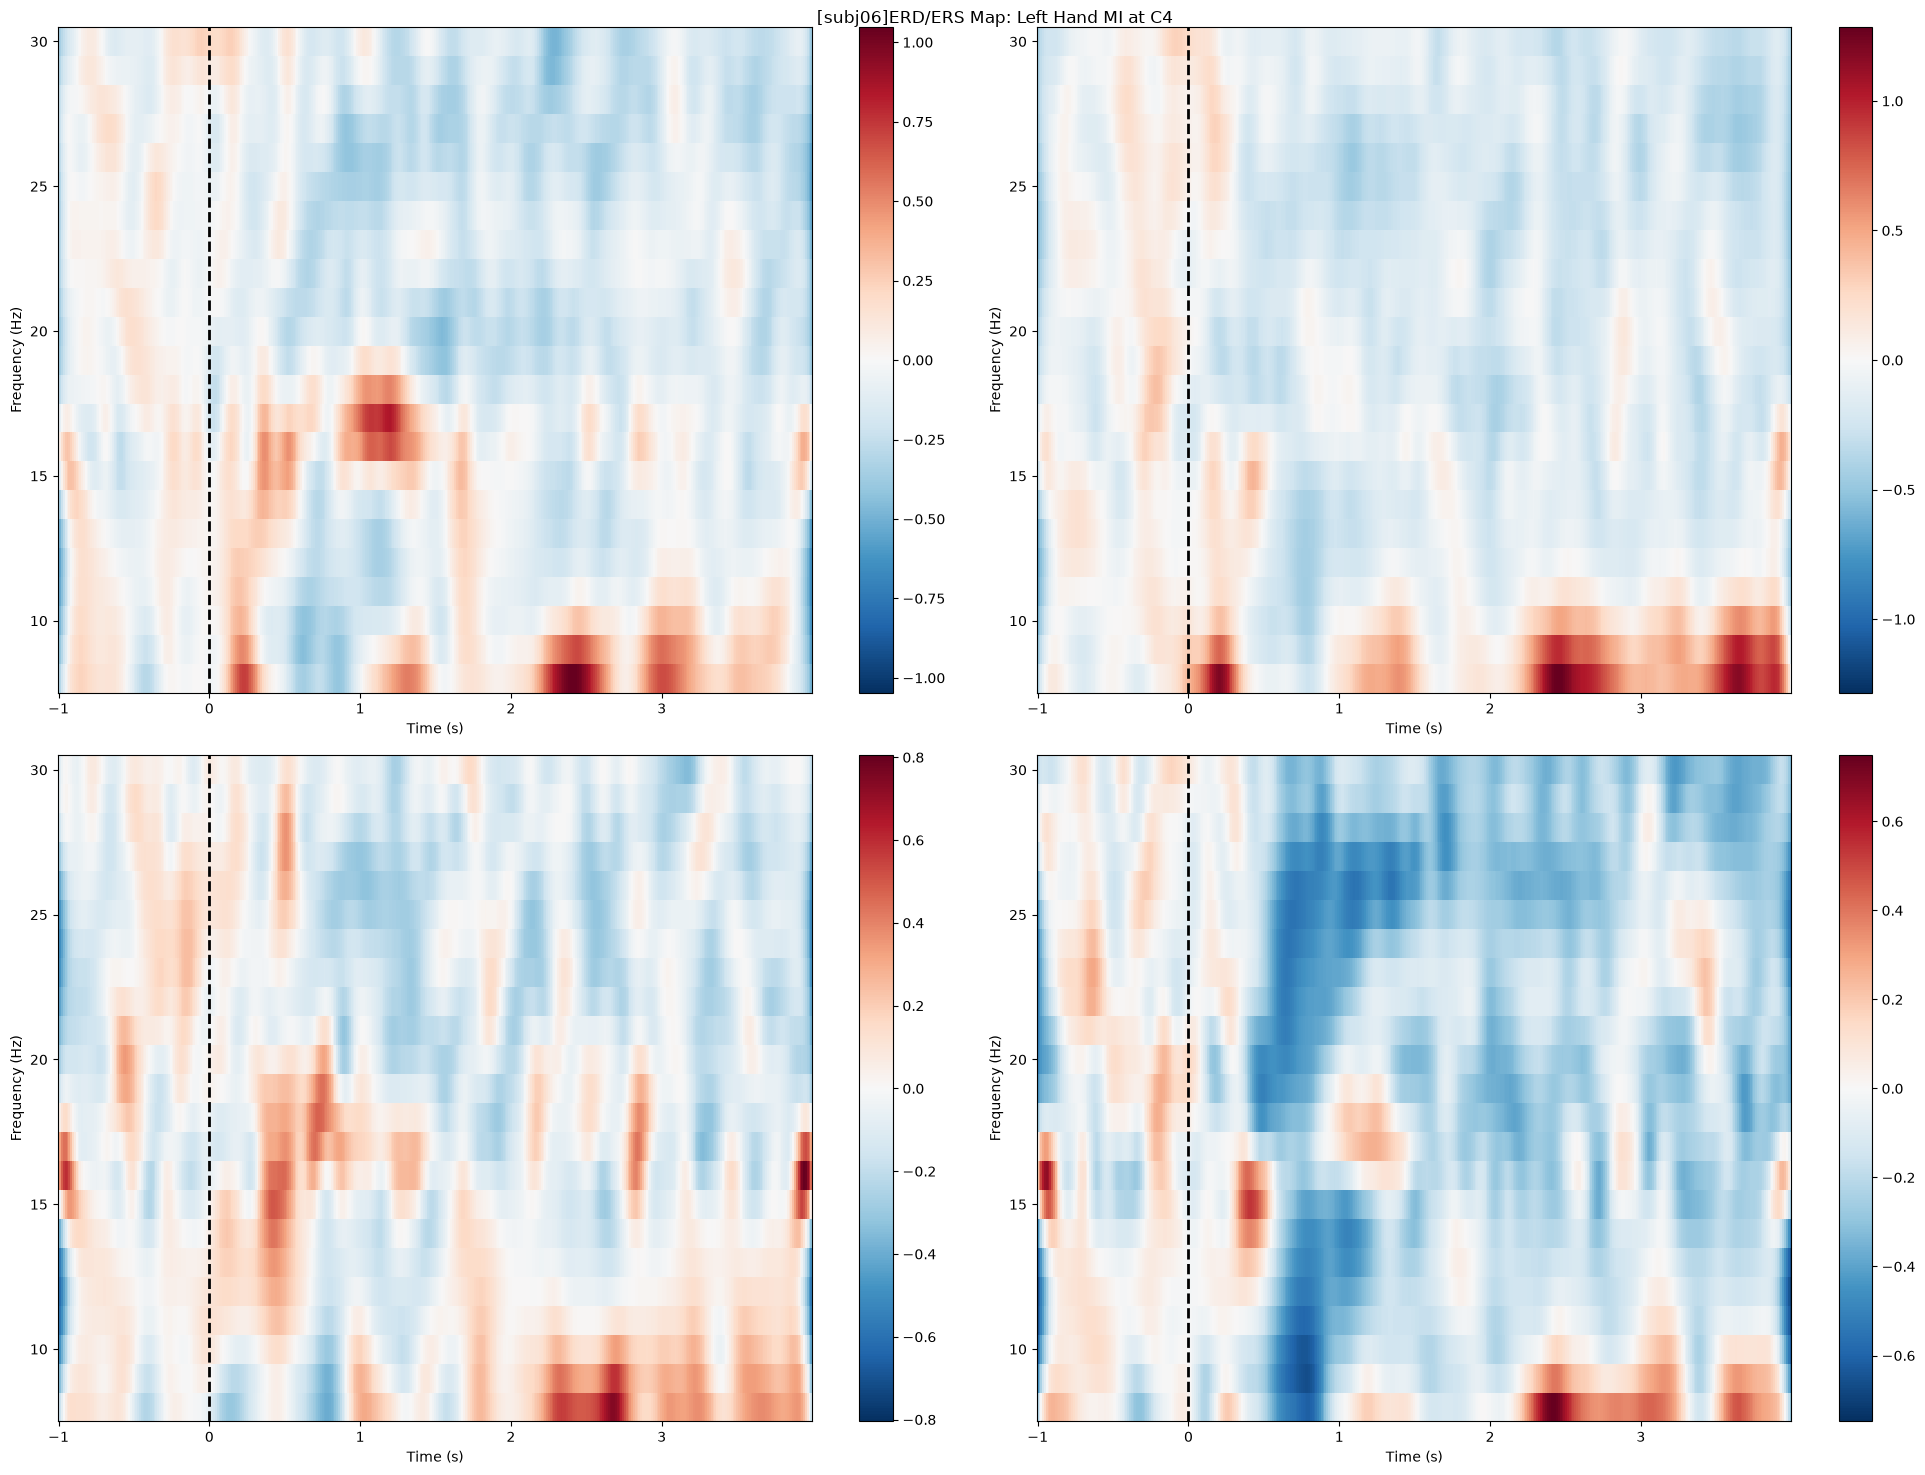

시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


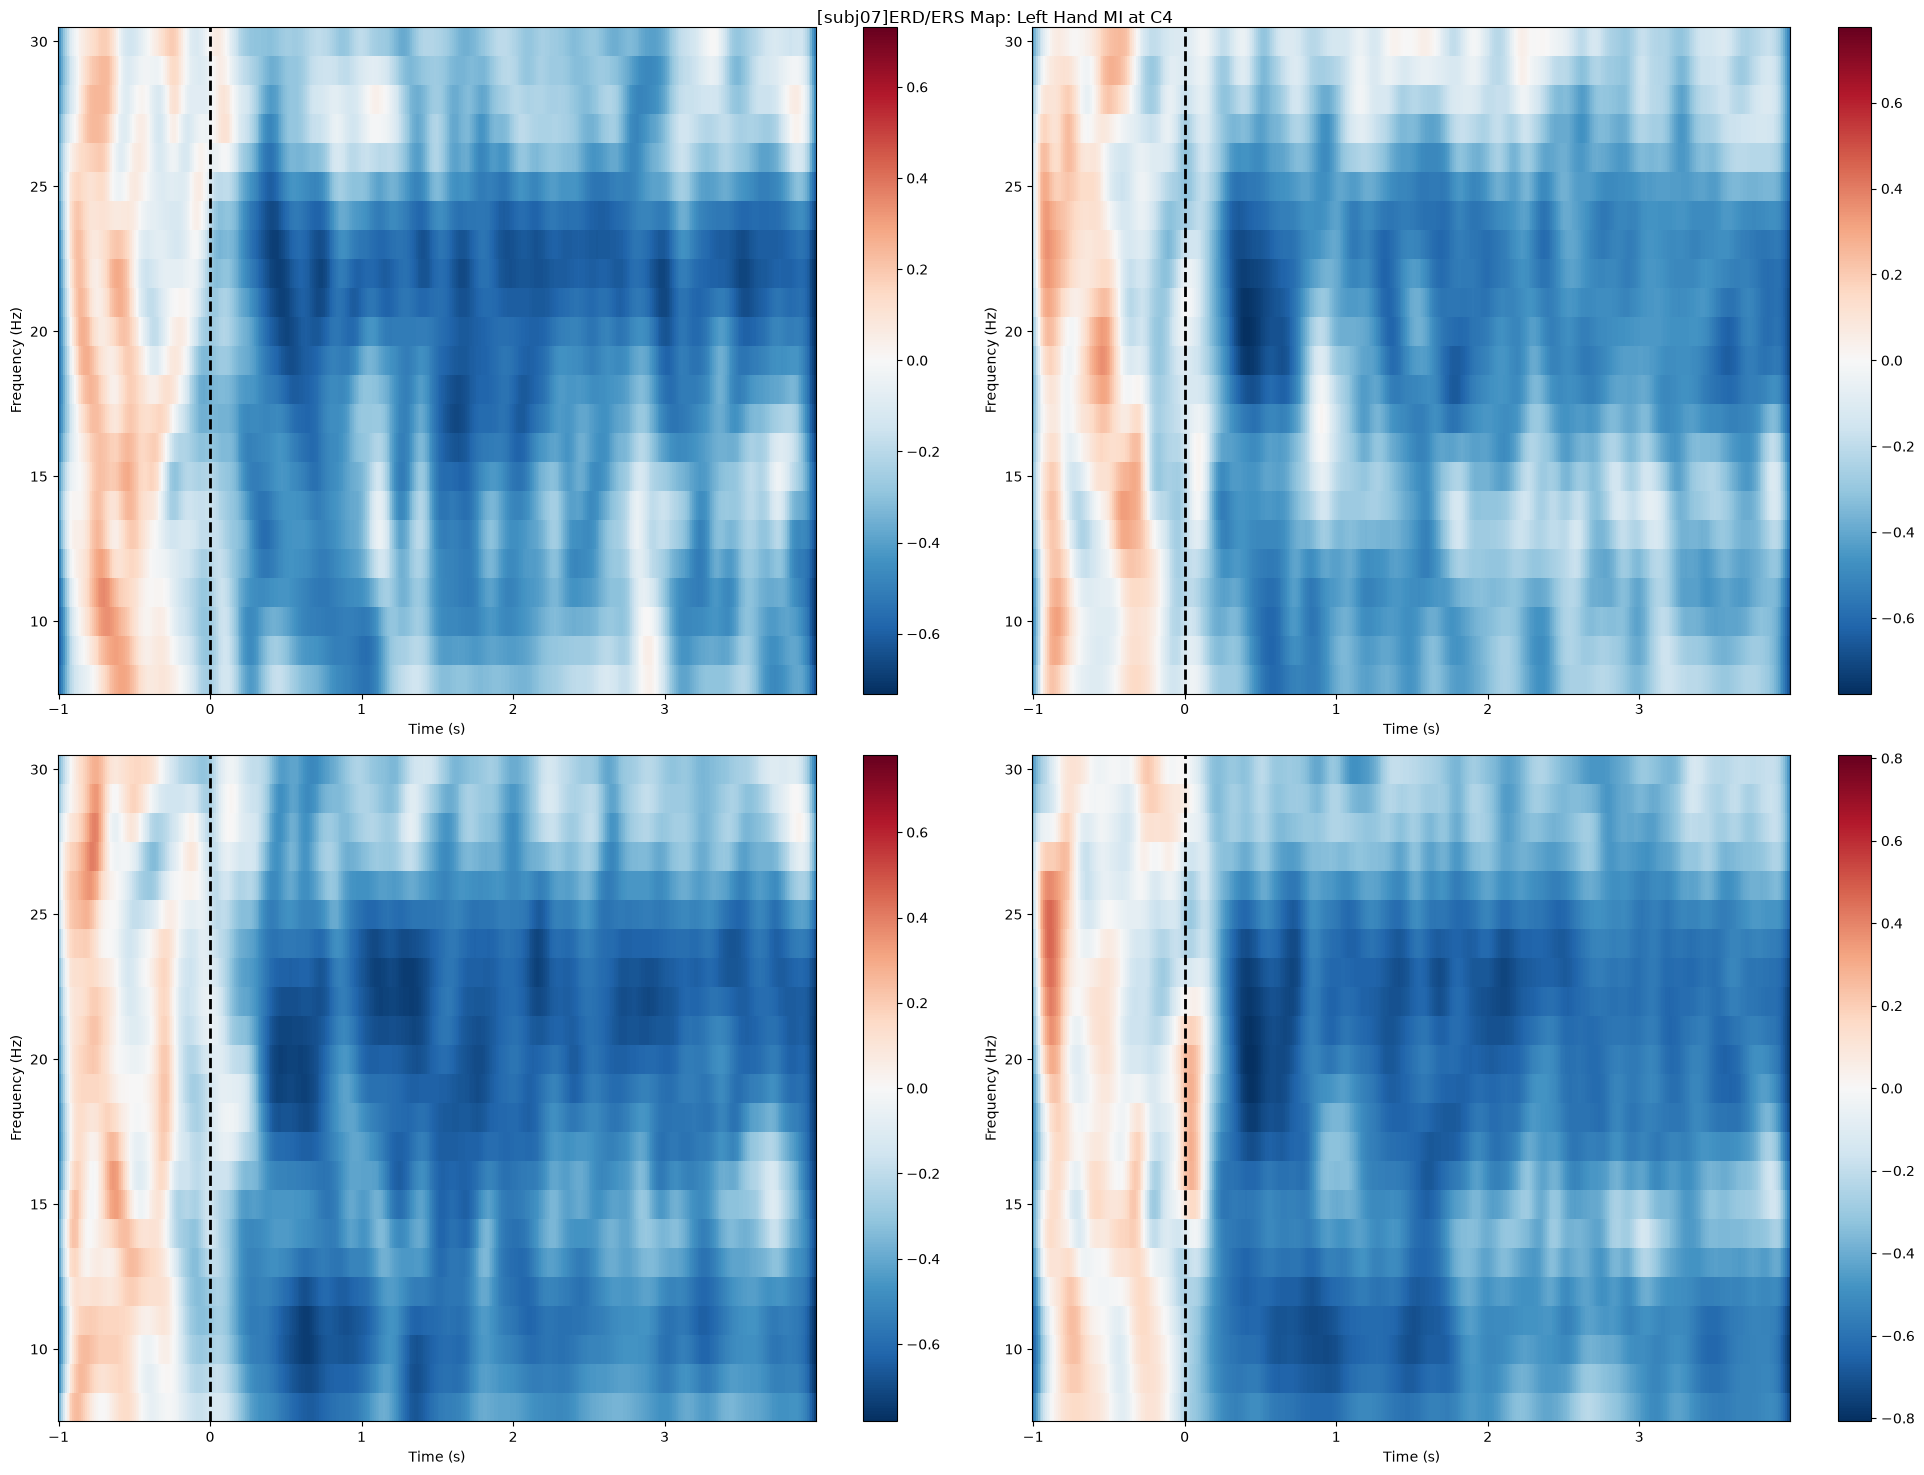

시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


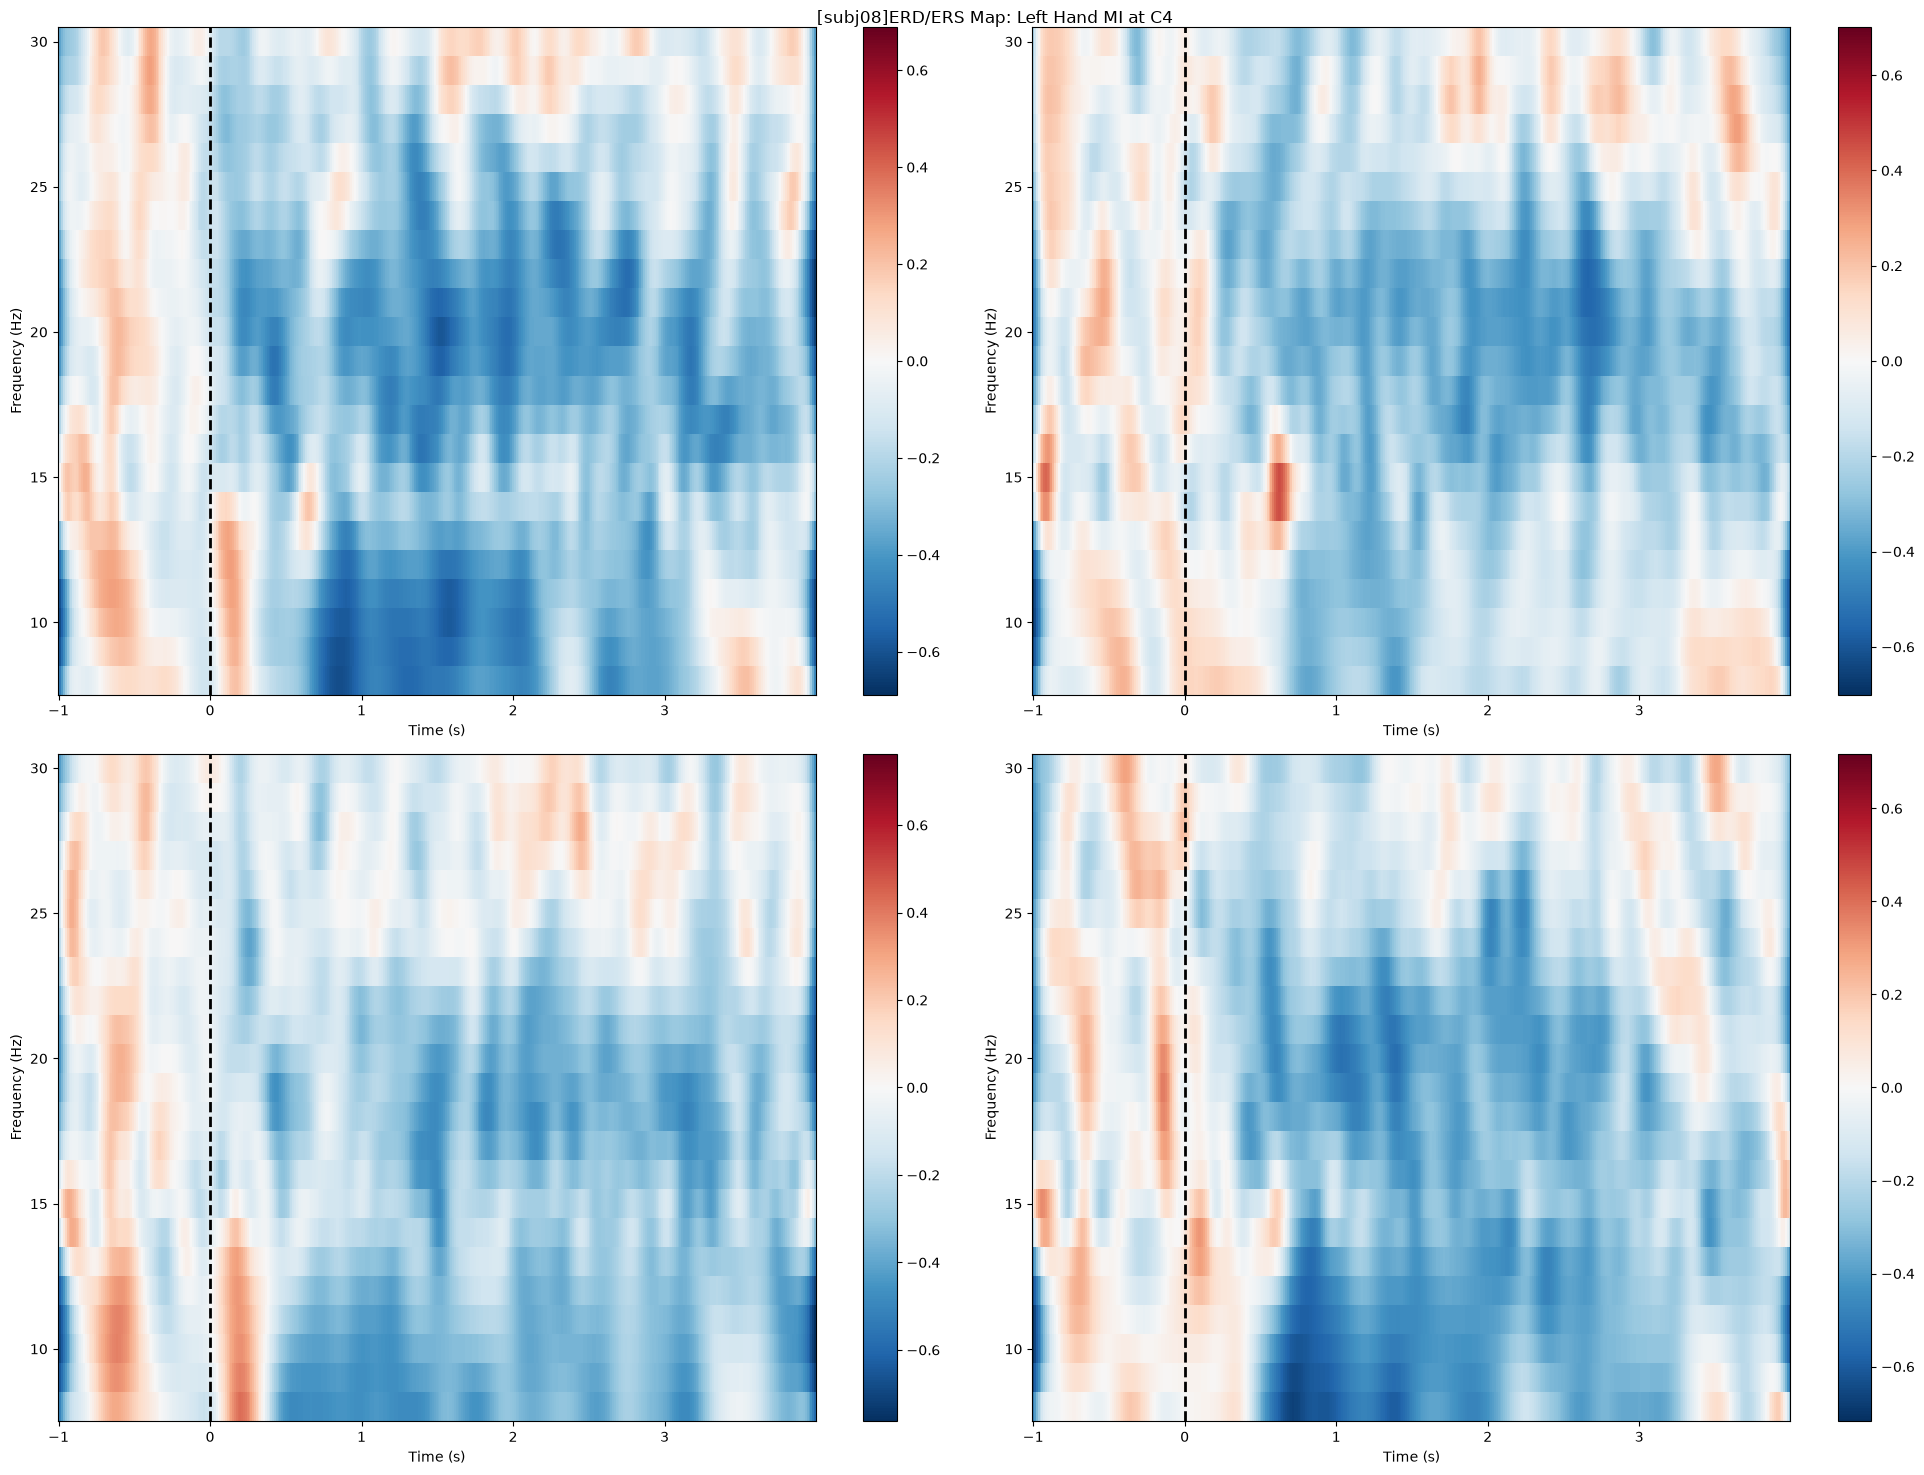

시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)
Applying baseline correction (mode: percent)


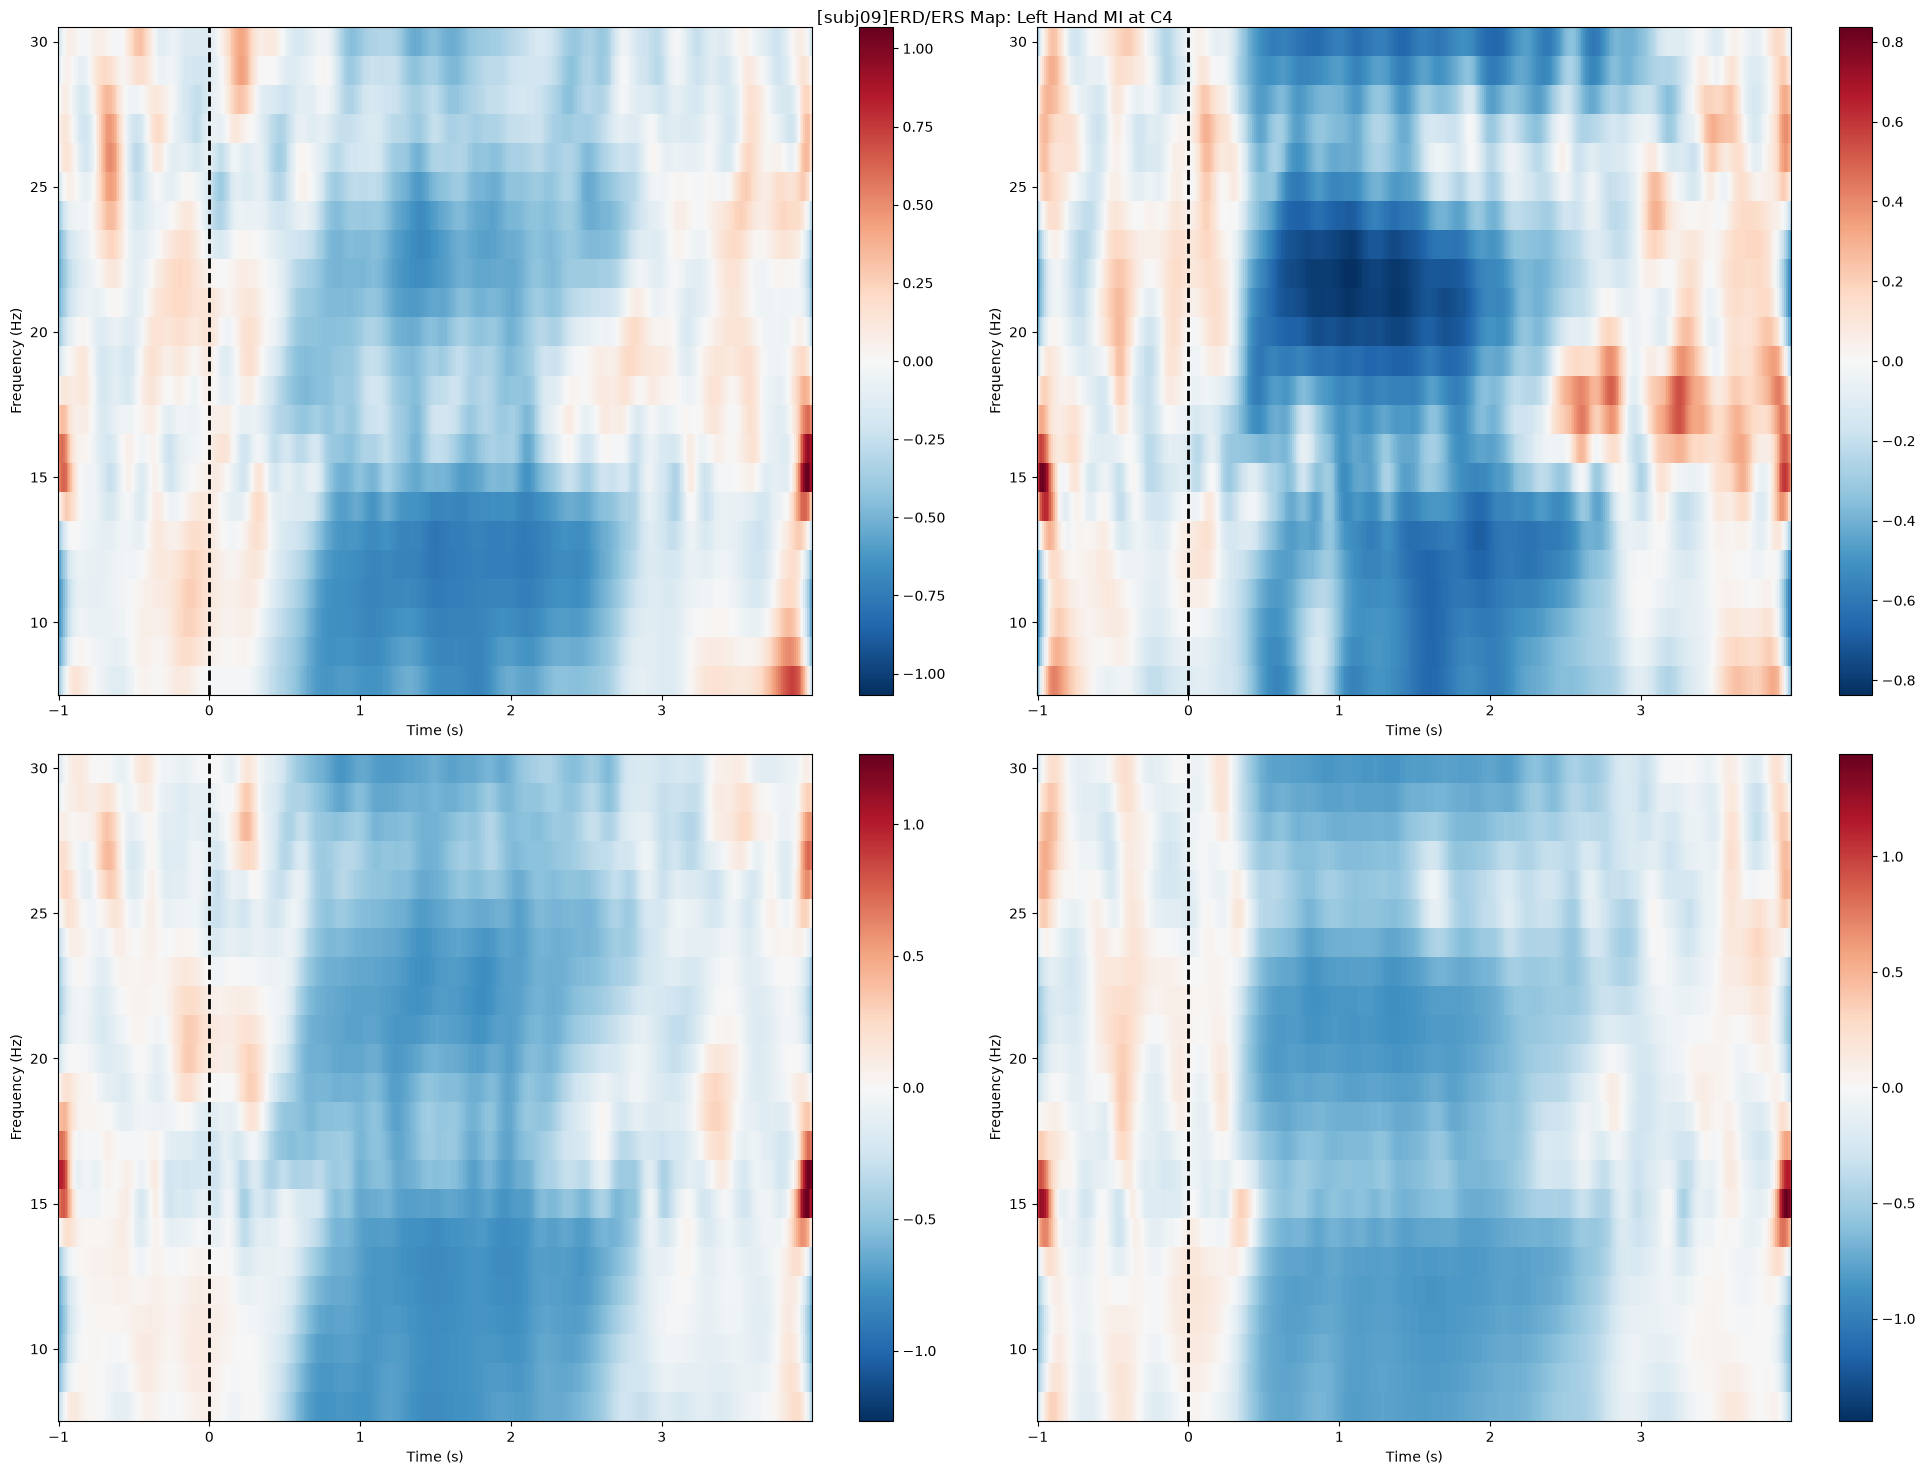

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mne.time_frequency import tfr_morlet

for i in range(9) : # subj 01~09까지
    # 0. 왼손 상상 에포크만 가져오기(데이터 설명 pdf에서 왼손 상상 에포크는 769임을 확인. + epochs.event_id로 실제로 존재함 확인.)
    epochs_left = epochs_subj_list[i]['769']

    # 1. 추적할 주파수 대역 설정 (Mu 밴드를 포함한 8~30Hz)
    freqs = np.arange(8.0, 31.0, 1.0)
    n_cycles = freqs / 2.0 

    print("시간-주파수 분석(TFR) 계산 중... (수 초 소요될 수 있습니다)")
    # 2. 왼손 상상 데이터(epochs_left)의 TFR 계산 -> TFR에는  EpochsTFR과 AverageTFR이 있고, 여기선 Epochs TFR이다. -> Epochs TFR은 아래 vmin, vmax를 쓸 수 없다.
    power_left = tfr_morlet(epochs_left, freqs=freqs, n_cycles=n_cycles, use_fft=True,
                            return_itc=False, decim=3, n_jobs=1, average=True)

    # 3. ERD/ERS 시각화 (C1/C2, C3/C4 전극)
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 15)) # 2행 2열구조(1행 C1/C2, 2행 C3/C4)

    # C1/C2, C3/C4의 그래프 설정 (vmin, vmax는 Epochs TFR에서 쓸 수 없다.)

    power_left.plot(picks=['C1'], baseline=(-1.0, 0), mode='percent', 
                    axes=ax[0][0], title=f"[subj0{i+1}]ERD/ERS Map: Left Hand MI at C1", 
                    show=False) 
    ax[0][0].axvline(0, color='black', linestyle='--', linewidth=2) # 지시 시점(0초) 기준선

    power_left.plot(picks=['C2'], baseline=(-1.0, 0), mode='percent', 
                    axes=ax[0][1], title=f"[subj0{i+1}]ERD/ERS Map: Left Hand MI at C2", 
                    show=False) 
    ax[0][1].axvline(0, color='black', linestyle='--', linewidth=2)



    power_left.plot(picks=['C3'], baseline=(-1.0, 0), mode='percent', 
                    axes=ax[1][0], title=f"[subj0{i+1}]ERD/ERS Map: Left Hand MI at C3", 
                    show=False) 
    ax[1][0].axvline(0, color='black', linestyle='--', linewidth=2)


    power_left.plot(picks=['C4'], baseline=(-1.0, 0), mode='percent', 
                    axes=ax[1][1], title=f"[subj0{i+1}]ERD/ERS Map: Left Hand MI at C4", 
                    show=False) 

    ax[1][1].axvline(0, color='black', linestyle='--', linewidth=2)



    plt.tight_layout()
    plt.show()



# 가설 1-2에 대한 추가 실험 결과 분석 1
이론적 이상 : 왼손 상상 기준으로 가장 좋은 패턴은 C2, C4가 확연히 파란색이고(진하기-주파수영역-지속시간 순으로 중요함.), C1, C3는 비교적 덜 파랗거나 빨간색을 띈다.
<br>
<br>
분류 기준 1. MI 지시 전과 후의 차이가 유의미한 subj 분류.  
- 유의미  
- subj 01  
- subj 03  
- subj 06  
- subj 07  
- subj 08  
- subj 09  
<br>
- 애매함  
    - subj 04
        - 특이점 1 : C1/C2는 C2가 더 ERD가 잘 나타남(25~30Hz). C3/C4는 반대임. 따라서 이 subj에겐 C1/C2을 선택하는게 더 적합해 보인다. -> 더 명확히 보려면 이 프로젝트의 목적을 떠올리면 됨. 이 프로젝트의 목적은 왼손/오른손 MI 데이터만 주어졌을 때 왼손인지 오른손인지를 잘 판별하는 것이므로 C1/C2, C3/C4에 대해 지금처럼 왼손뿐 만 아니라 오른손도 같이 비교해서 왼손과 오른손의 차이가 확연히 나는지 봐야 함.

    - subj 05
        - 특이점 1 : C1/C2의 경우엔 2초 이전은 ERD가 나타나지만 C1과 C2 사이의 차이가 뚜렷하지 않고, 2초 이후엔 ERD가 잘 나타나지 않지만 C1과 C2의 차이가 비교적 뚜렷하다. C3/C4의 경우엔 25~30Hz 구간은 ERD와 양반구의 그 차이가 잘 나타나는데, 15~25Hz 구간은 양반구의 차이가 반대로 나타난다.(C3가 더 ERD가 강함.)
<br>
- 무의미  
    - subj 02
        - 특이점 1 : 오른쪽 반구에 해당하는 C2, C4 모두 ERD가 나타나지 않으며 오히려 빨간색의 시간 단위 당 면적이 커지고(ERD가 나타나지 않은 주파수가 더 많아짐.), 오히려 더 빨간색이 진해지는 구간도 있음.
        - 특이점 2 : C1/C2의 경우엔 오히려 C1이 빨강, 파랑 모두 색의 진하기가 더 진함. C3/C4의 경우엔 C4가 빨강, 파랑 모두 색의 진하기가 더 진함. -> C3/C4가 왼손 MI 이론에 더 적합함.
    <br>
    --> 원인 분석 : 데이터셋 설명에선 subj 02에 대한 특이사항 기재되지 않음. 내 생각엔 기기 이상 혹은 피실험자의 실수 혹은 피실험자만의 특성이라 생각할 수 있으며, 확인 방법은 떠오르지 않는다. 이 같은 경우에 실전에선 데이터 자체가 잘못되지 않는 한 개인만을 위한 조정을 가한다.

# 추가실험 결과 분석에 대한 피드백
- 이론적 이상 : 왼손 상상 기준으로 가장 좋은 패턴은 C2, C4가 확연히 파란색이고(진하기-주파수영역-지속시간 순으로 중요함.), C1, C3는 비교적 덜 파랗거나 빨간색을 띈다.
- 적합한 데이터 부분만 자르기 : TFR을 색의 진하기, 색이 차지하는 주파수 영역, 색의 지속시간으로 나눠서 보면, 훈련용으로 쓸 수 있는 이론에 적합한 구역들을 잘라낼 수 있다. 다만, 이론에 적합한 것만이 훈련용 데이터에 들어가야만 하는 건 아닌 것 같다. 개인차도 고려해야 하는데, 이건 일반적인 모델을 만들고 후에 전이학습과 미세조정으로 개인차에 맞춰야 한다고 생각한다. -> 이번 프로젝트에선 사전 학습용 데이터를 뽑아내야 하므로 이론에 적합한 데이터만 쓰는 것이 아닌 개인의 다양성이 담길 수 있게 데이터를 골라야 한다. 따라서 애매함, 무의미 판정을 내린 subj 02, 04, 05 또한 다양성을 추가하기 위해 그대로 훈련용 데이터로 써야 한다.



# 가설 1-2에 대한 추가 실험 결과 분석 2
그래서 C1/C2, C3/C4 중에 뭘 쓸 것인가? : 사실, CSP 알고리즘은 '가장 뚜렷한 차이'를 알아서 찾아주기에 둘 중에 하나만 넣는 건 효과가 없으며, 오히려 내가 육안으로만 확인한 걸 근거로 어느 한쪽을 훈련 데이터에서 제외시키는 것이 더 위험하다. 따라서 둘 다 넣는 것이 타당하다.
<br>
<br>
그럼 가설 1-2에 대한 추가실험이 갖는 의의는? : C1/C2, C3/C4 중에 뭐가 더 좌/우뇌 지배기전에 따른 좌/우반구의 ERD 패턴 차이를 잘 보여주냐? 라는 의문에서 시작했고, 그것에 답하는게 중요하지 않음을 알았다. 그러나 의의는 있다. 여러 subj의 TFR을 보면서 좌/우반구의 ERD 패턴차이를 볼 수 있는 눈을 가질 수 있었다. 또한, 개인차를 확인하였고, 그것을 훈련용 데이터에 넣을지 말지 생각하는 과정에서 어떤 데이터가 좋은 데이터인지 생각해볼 수 있었다.

# 의문 1에 대한 답
EEG에 담긴 왼/오른손 MI에서 나타나는 ERD 특성은 ICA를 통한 노이즈 제거 과정에서 사라지지 않았다.

# 의문 2. CSP의 파라미터를 조절하면 성능을 더 높일 수 있지 않을까?

## CSP 파라미터

motor channels

n_components

reg

log

norm

trace

In [ ]:
# 가설 1-2에서 저장된 subj 01의 epochs 불러오기
import mne
epochs = mne.read_epochs("../dataset/epochs/A01T-epoch.fif", preload=True)

Reading e:\workspace\BCI_Project_ICA-CSP\notebooks\..\dataset\epochs\A01T-epoch.fif ...
Isotrak not found
    Found the data of interest:
        t =   -1000.00 ...    4000.00 ms
        0 CTF compensation matrices available
Not setting metadata
584 matching events found
No baseline correction applied
0 projection items activated


C:\Users\hum05\AppData\Local\Temp\ipykernel_25536\4068756190.py:3: RuntimeWarning: This filename (../dataset/epochs/A01T-epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs("../dataset/epochs/A01T-epoch.fif", preload=True)


In [4]:
import pandas as pd
from mne.decoding import CSP

print("--- 🚜 12~13일 차: 타겟팅 CSP 불도저 가동 ---")

# 1. 핀셋 타겟팅: 왼손(769)과 오른손(770) 상상 데이터만 추출

epochs_mi = epochs['769', '770'] 
epochs_mi_eeg = epochs_mi.copy().pick_types(eeg=True, eog=False)
# 2. 순수 EEG 채널 중에서도 앞/뒤 뇌파를 잘라내고 '운동 피질' 주변만 핀셋 추출
# C(중심엽), FC(전두중심엽), CP(중심두정엽) 라인의 전극만 선택하여 모델의 시야를 강제로 좁힙니다.
motor_channels = ['FC3', 'FC1', 'FCz', 'FC2', 'FC4', 
                  'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 
                  'CP3', 'CP1', 'CPz', 'CP2', 'CP4']

# 기존 22개 차원에서 17개 차원으로 축소
epochs_mi_motor = epochs_mi_eeg.copy().pick_channels(motor_channels)
# 2. 머신러닝 모델에 넣을 3차원 특징 데이터(X)와 정답 라벨(y) 분리
X = epochs_mi_motor.get_data(copy=True) # epochs.get_data()는 (Epochs, Channels, Time) 형태의 3차원 배열을 반환합니다.
y = epochs_mi_motor.events[:, -1] # 이벤트 배열의 마지막 열이 라벨(예: 769, 770)입니다.

# 3. CSP 모델 생성 및 학습
# 수정할 부분
csp = CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=True)
csp.fit(X, y)
print("CSP 돋보기 학습 완료!")

# 4. CSP 공간 패턴 시각화
csp.plot_patterns(epochs_mi_motor.info, ch_type='eeg', units='Patterns (AU)', size=1.5)

--- 🚜 12~13일 차: 타겟팅 CSP 불도저 가동 ---
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
    Using tolerance 8.1e-06 (2.2e-16 eps * 17 dim * 2.2e+09  max singular value)
    Estimated rank (data): 17
    data: rank 17 computed from 17 data channels with 0 projectors
Reducing data rank from 17 -> 17
Estimating class=7 covariance using LEDOIT_WOLF
Done.
Estimating class=8 covariance using LEDOIT_WOLF
Done.
CSP 돋보기 학습 완료!
NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


RuntimeError: No digitization points found.